# PUC-Rio  
## Departamento de Engenharia Elétrica  
## ELE2398 — Redes Neurais  

**Aluno:** Carlos Alberto de Souza Moreira Junior  
**Matrícula:** 2612398  

**Professores:** Thiago Medeiros/Marley 

# Lista de Exercícios 3 — Mapas Auto-Organizáveis (SOM)
## Aplicação: Diagnóstico de Doenças da Tireoide

Nesta lista de exercícios, você fará uma exploração empírica profunda dos **hiperparâmetros** do Mapa Auto-Organizável (SOM). A ideia é testar os efeitos de cada parâmetro de forma isolada, culminando na escolha de uma configuração adequada para explorar e agrupar dados de diagnóstico médico.

**Base de Dados (`c_thyroid.csv`):**
A base de dados contém pacientes classificados em 3 condições da tireoide (coluna `target`):
* `1.0`: Normal
* `2.0`: Hipertireoidismo
* `3.0`: Hipotireoidismo

---
### Preparação do Ambiente
Copie a classe `SelfOrganizingMap` completa do notebook anterior (SOM - Hands-on) e execute-a na célula abaixo. Importe também as bibliotecas necessárias.


In [32]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from collections import defaultdict, Counter
from tqdm.auto import tqdm

In [33]:
"""import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from tqdm.auto import tqdm  """

class SelfOrganizingMap:
    """
    Implementacao completa de um Mapa Auto-Organizavel (SOM) em PyTorch.
    Suporta topologias retangular e hexagonal, multiplas funcoes de
    vizinhanca e decaimento, e visualizacoes profissionais.
    """

    def __init__(self, m, n, input_dim, topology='rectangular',
                 neighborhood_fn='gaussian', decay_fn='exponential',
                 init_method='pca', random_seed=42):
        self.m = m
        self.n = n
        self.input_dim = input_dim
        self.topology = topology
        self.neighborhood_fn_name = neighborhood_fn
        self.decay_fn_name = decay_fn
        self.init_method = init_method
        self.n_neurons = m * n

        torch.manual_seed(random_seed)
        np.random.seed(random_seed)

        self.grid_positions = self._compute_grid_positions()
        self.pairwise_distances = torch.cdist(
            self.grid_positions.unsqueeze(0),
            self.grid_positions.unsqueeze(0)
        ).squeeze(0)

        self.weights = None
        self._total_iterations = 0
        self.history = {
            'iteration': [], 'qe': [], 'te': [], 'lr': [], 'sigma': []
        }
        self.phase_boundaries = []

    # ═══════════ TOPOLOGY ═══════════

    def _compute_grid_positions(self):
        positions = torch.zeros(self.n_neurons, 2)
        for i in range(self.m):
            for j in range(self.n):
                k = i * self.n + j
                if self.topology == 'hexagonal':
                    positions[k, 0] = j + 0.5 * (i % 2)
                    positions[k, 1] = i * np.sqrt(3) / 2
                else:
                    positions[k, 0] = float(j)
                    positions[k, 1] = float(i)
        return positions

    def _get_neighbors(self, idx):
        i = idx // self.n
        j = idx % self.n
        neighbors = []
        if self.topology == 'rectangular':
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < self.m and 0 <= nj < self.n:
                    neighbors.append(ni * self.n + nj)
        else:
            if i % 2 == 0:
                offsets = [(-1, -1), (-1, 0), (0, -1), (0, 1), (1, -1), (1, 0)]
            else:
                offsets = [(-1, 0), (-1, 1), (0, -1), (0, 1), (1, 0), (1, 1)]
            for di, dj in offsets:
                ni, nj = i + di, j + dj
                if 0 <= ni < self.m and 0 <= nj < self.n:
                    neighbors.append(ni * self.n + nj)
        return neighbors

    def _neuron_xy(self, k):
        """Coordenadas (x, y) do neuronio k na grade."""
        i, j = k // self.n, k % self.n
        if self.topology == 'hexagonal':
            return j + 0.5 * (i % 2), i * np.sqrt(3) / 2
        return float(j), float(i)

    def _hex_vertices(self, cx, cy):
        """Vertices de um hexagono pointy-top centrado em (cx, cy).

        Para a grade com espacamento horizontal = 1 e vertical = sqrt(3)/2,
        o raio circunscrito eh R = 1/sqrt(3).  Os vertices ficam em angulos
        30, 90, 150, 210, 270, 330 graus, o que produz arestas verticais
        entre vizinhos horizontais e encaixe perfeito na grade offset.
        """
        R = 1.0 / np.sqrt(3)
        angles = [np.pi / 6 + k * np.pi / 3 for k in range(6)]
        return [(cx + R * np.cos(a), cy + R * np.sin(a)) for a in angles]

    # ═══════════ INITIALIZATION ═══════════

    def initialize(self, data):
        if self.init_method == 'pca':
            self._init_weights_pca(data)
        else:
            self._init_weights_random(data)

    def _init_weights_random(self, data):
        lo = data.min(dim=0).values
        hi = data.max(dim=0).values
        self.weights = lo + torch.rand(self.n_neurons, self.input_dim) * (hi - lo)

    def _init_weights_pca(self, data):
        mean = data.mean(dim=0)
        centered = data - mean
        cov = (centered.T @ centered) / (len(data) - 1)
        eigenvalues, eigenvectors = torch.linalg.eigh(cov)
        idx = torch.argsort(eigenvalues, descending=True)
        eigenvalues = eigenvalues[idx].clamp(min=0)
        eigenvectors = eigenvectors[:, idx]
        pc1 = eigenvectors[:, 0]
        pc2 = eigenvectors[:, 1] if self.input_dim >= 2 else torch.zeros_like(pc1)
        self.weights = torch.zeros(self.n_neurons, self.input_dim)
        for k in range(self.n_neurons):
            c1 = (2.0 * (k // self.n) / max(self.m - 1, 1)) - 1.0
            c2 = (2.0 * (k % self.n) / max(self.n - 1, 1)) - 1.0
            self.weights[k] = (mean
                               + c1 * torch.sqrt(eigenvalues[0]) * pc1
                               + c2 * torch.sqrt(eigenvalues[1]) * pc2)

    # ═══════════ NEIGHBORHOOD ═══════════

    def _neighborhood(self, bmu_idx, sigma):
        d = self.pairwise_distances[bmu_idx]
        if self.neighborhood_fn_name == 'gaussian':
            return torch.exp(-d ** 2 / (2 * sigma ** 2))
        elif self.neighborhood_fn_name == 'bubble':
            return (d <= sigma).float()
        elif self.neighborhood_fn_name == 'mexican_hat':
            d2s2 = d ** 2 / (sigma ** 2)
            return (1 - d2s2) * torch.exp(-d2s2 / 2)
        raise ValueError(f"Vizinhanca desconhecida: {self.neighborhood_fn_name}")

    # ═══════════ DECAY ═══════════

    def _decay(self, start, end, step, total_steps):
        if total_steps == 0:
            return start
        t = step / total_steps
        if self.decay_fn_name == 'linear':
            return start + (end - start) * t
        elif self.decay_fn_name == 'exponential':
            return start * (max(end, 1e-8) / start) ** t
        elif self.decay_fn_name == 'inverse':
            return start / (1 + step * (start / max(end, 1e-8) - 1) / total_steps)
        raise ValueError(f"Decaimento desconhecido: {self.decay_fn_name}")

    # ═══════════ TRAINING ═══════════

    def _find_bmu(self, x):
        return torch.argmin(torch.norm(self.weights - x, dim=1))

    @torch.no_grad()
    def train(self, data, n_iterations, lr_start, lr_end,
              sigma_start, sigma_end, phase_name='',
              eval_every=100, verbose=True):
        n_samples = len(data)
        pbar = tqdm(range(n_iterations), desc=phase_name, disable=not verbose)
        for step in pbar:
            x = data[np.random.randint(n_samples)]
            lr = self._decay(lr_start, lr_end, step, n_iterations)
            sigma = self._decay(sigma_start, sigma_end, step, n_iterations)
            bmu = self._find_bmu(x)
            h = self._neighborhood(bmu, sigma)
            self.weights += lr * h.unsqueeze(1) * (x - self.weights)
            if (step + 1) % eval_every == 0 or step == n_iterations - 1:
                qe = self.quantization_error(data)
                te = self.topographic_error(data)
                self.history['iteration'].append(self._total_iterations + step + 1)
                self.history['qe'].append(qe)
                self.history['te'].append(te)
                self.history['lr'].append(lr)
                self.history['sigma'].append(sigma)
                if verbose:
                    pbar.set_postfix({'QE': f'{qe:.4f}', 'TE': f'{te:.4f}'})
        self._total_iterations += n_iterations
        self.phase_boundaries.append((phase_name, self._total_iterations))

    # ═══════════ METRICS ═══════════

    def quantization_error(self, data):
        return torch.cdist(data, self.weights).min(dim=1).values.mean().item()

    def topographic_error(self, data):
        dists = torch.cdist(data, self.weights)
        top2 = torch.topk(dists, 2, dim=1, largest=False)
        bmu1, bmu2 = top2.indices[:, 0], top2.indices[:, 1]
        return (self.pairwise_distances[bmu1, bmu2] > 1.1).float().mean().item()

    def compute_umatrix(self):
        u = torch.zeros(self.n_neurons)
        for k in range(self.n_neurons):
            nbs = self._get_neighbors(k)
            if nbs:
                u[k] = torch.norm(self.weights[k] - self.weights[nbs], dim=1).mean()
        return u

    # ═══════════ VISUALIZATION CORE ═══════════

    def _setup_hex_axes(self, ax):
        R = 1.0 / np.sqrt(3)
        pad = 0.15
        x_lo = -R - pad
        x_hi = (self.n - 1) + 0.5 + R + pad
        y_lo = -R - pad
        y_hi = (self.m - 1) * np.sqrt(3) / 2 + R + pad
        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_hi, y_lo)          # inverted
        ax.set_aspect('equal')

    def _plot_grid(self, values, title='', cmap='viridis', ax=None,
                   colorbar=True, vmin=None, vmax=None):
        """Plota valores na grade do SOM (retangular ou hexagonal)."""
        if isinstance(values, torch.Tensor):
            values = values.numpy()
        own_fig = ax is None
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 9))
        vmin = vmin if vmin is not None else values.min()
        vmax = vmax if vmax is not None else values.max()
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap_obj = plt.cm.get_cmap(cmap)

        if self.topology == 'rectangular':
            grid = values.reshape(self.m, self.n)
            im = ax.pcolormesh(
                np.arange(self.n + 1) - 0.5,
                np.arange(self.m + 1) - 0.5,
                grid, cmap=cmap, vmin=vmin, vmax=vmax,
                edgecolors='#eeeeee', linewidth=0.5, shading='flat')
            ax.set_xlim(-0.5, self.n - 0.5)
            ax.set_ylim(self.m - 0.5, -0.5)
            ax.set_aspect('equal')
        else:
            patches_list = []
            colors_list = []
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patches_list.append(Polygon(verts, closed=True))
                colors_list.append(cmap_obj(norm(values[k])))
            coll = PatchCollection(patches_list, match_original=False)
            coll.set_facecolors(colors_list)
            coll.set_edgecolors('white')
            coll.set_linewidths(0.8)
            coll.set_zorder(1)
            ax.add_collection(coll)
            self._setup_hex_axes(ax)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if colorbar:
            if self.topology == 'rectangular':
                cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
                sm.set_array([])
                cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=10)

        if title:
            ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
        return ax

    # ═══════════ VISUALIZATIONS ═══════════

    def plot_umatrix(self, ax=None):
        return self._plot_grid(self.compute_umatrix(),
                               title='U-Matrix', cmap='RdYlBu_r', ax=ax)

    def plot_component_planes(self, feature_names=None):
        nf = self.input_dim
        if feature_names is None:
            feature_names = [f'Feature {i}' for i in range(nf)]
        ncols = min(3, nf)
        nrows = int(np.ceil(nf / ncols))
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5.5 * ncols, 5 * nrows))
        axes = np.array(axes).flatten()
        for i in range(nf):
            vals = self.weights[:, i].detach().numpy()
            self._plot_grid(vals, title=feature_names[i],
                            cmap='coolwarm', ax=axes[i])
        for i in range(nf, len(axes)):
            axes[i].set_visible(False)
        fig.suptitle('Planos de Componentes',
                     fontsize=16, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

    def plot_hit_map(self, data, ax=None):
        bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
        hits = torch.zeros(self.n_neurons)
        for b in bmus:
            hits[b] += 1
        show = ax is None
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 9))
        self._plot_grid(hits, title='Mapa de Ativacao (Hit Map)',
                        cmap='YlOrRd', ax=ax)
        max_h = max(hits.max().item(), 1)
        for k in range(self.n_neurons):
            if hits[k] > 0:
                x, y = self._neuron_xy(k)
                r = 0.25 * np.sqrt(hits[k].item() / max_h) + 0.05
                circle = plt.Circle((x, y), r, facecolor='white',
                                    edgecolor='#333333', linewidth=0.8,
                                    alpha=0.85, zorder=3)
                ax.add_patch(circle)
                ax.text(x, y, f'{int(hits[k])}', ha='center', va='center',
                        fontsize=6, fontweight='bold', color='#333333',
                        zorder=4)
        if show:
            plt.tight_layout()
            plt.show()
        return ax

    def plot_winner_map(self, data, labels, colors_dict=None,
                        country_codes=None, category_color=None):
        fig, ax = plt.subplots(figsize=(14, 12))
        umatrix = self.compute_umatrix()
        self._plot_grid(umatrix, cmap='bone_r', ax=ax, colorbar=False)
        bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
        bmu_labels = defaultdict(list)
        for idx_s, bmu in enumerate(bmus):
            bmu_labels[bmu.item()].append(labels[idx_s])
            
        for bmu_idx, label_list in bmu_labels.items():
            x, y = self._neuron_xy(bmu_idx)
            for kk, label in enumerate(label_list):
                display = label
                if country_codes and len(label) > 6:
                    display = country_codes.get(label, label[:6])
                color = colors_dict.get(label, 'black') if colors_dict else 'black'
                y_off = (kk - len(label_list) / 2 + 0.5) * 0.12
                ax.text(x, y + y_off, display, ha='center', va='center',
                        fontsize=5.5, fontweight='bold', color=color,
                        path_effects=[pe.withStroke(linewidth=2,
                                                    foreground='white')],
                        zorder=5)
        if category_color:
            handles = [mpatches.Patch(color=c, label=cat)
                       for cat, c in category_color.items()]
            ax.legend(handles=handles, loc='upper left', fontsize=10,
                      framealpha=0.95, title='Categoria',
                      title_fontsize=11)
        ax.set_title('Mapa de Paises', fontsize=16,
                     fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()

    def plot_weight_vectors(self):
        pca = PCA(n_components=3)
        w3d = pca.fit_transform(self.weights.detach().numpy())
        wmin, wmax = w3d.min(axis=0), w3d.max(axis=0)
        rng = wmax - wmin
        rng[rng == 0] = 1
        w_rgb = (w3d - wmin) / rng
        fig, ax = plt.subplots(figsize=(10, 9))
        if self.topology == 'rectangular':
            ax.imshow(w_rgb.reshape(self.m, self.n, 3),
                      interpolation='nearest')
        else:
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patch = Polygon(verts, closed=True,
                                facecolor=w_rgb[k],
                                edgecolor='white', linewidth=0.8, zorder=1)
                ax.add_patch(patch)
            self._setup_hex_axes(ax)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title('Vetores de Peso (PCA -> RGB)',
                     fontsize=14, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()

    # ═══════════ TRAINING CURVES ═══════════

    def plot_training_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        iters = self.history['iteration']
        # QE
        ax1.plot(iters, self.history['qe'],
                 color='#1976D2', linewidth=2.2, alpha=0.9)
        ax1.fill_between(iters, self.history['qe'],
                         alpha=0.06, color='#1976D2')
        ax1.set_title('Erro de Quantizacao')
        ax1.set_xlabel('Iteracao')
        ax1.set_ylabel('QE')
        # TE
        ax2.plot(iters, self.history['te'],
                 color='#D32F2F', linewidth=2.2, alpha=0.9)
        ax2.fill_between(iters, self.history['te'],
                         alpha=0.06, color='#D32F2F')
        ax2.set_title('Erro Topografico')
        ax2.set_xlabel('Iteracao')
        ax2.set_ylabel('TE')
        for name, boundary in self.phase_boundaries[:-1]:
            for a in (ax1, ax2):
                a.axvline(x=boundary, color='#9E9E9E', linestyle='--',
                          alpha=0.7, label=f'Fim: {name}')
        for a in (ax1, ax2):
            a.grid(True, alpha=0.15, linestyle='--')
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)
            a.legend(framealpha=0.9)
        plt.tight_layout()
        plt.show()

    def plot_decay_curves(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        iters = self.history['iteration']
        ax1.plot(iters, self.history['lr'],
                 color='#388E3C', linewidth=2.2, alpha=0.9)
        ax1.fill_between(iters, self.history['lr'],
                         alpha=0.06, color='#388E3C')
        ax1.set_title('Taxa de Aprendizado ($\\eta$)')
        ax1.set_xlabel('Iteracao')
        ax1.set_ylabel('$\\eta$')
        ax2.plot(iters, self.history['sigma'],
                 color='#7B1FA2', linewidth=2.2, alpha=0.9)
        ax2.fill_between(iters, self.history['sigma'],
                         alpha=0.06, color='#7B1FA2')
        ax2.set_title('Raio de Vizinhanca ($\\sigma$)')
        ax2.set_xlabel('Iteracao')
        ax2.set_ylabel('$\\sigma$')
        for name, boundary in self.phase_boundaries[:-1]:
            for a in (ax1, ax2):
                a.axvline(x=boundary, color='#9E9E9E', linestyle='--',
                          alpha=0.7, label=f'Fim: {name}')
        for a in (ax1, ax2):
            a.grid(True, alpha=0.15, linestyle='--')
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)
            a.legend(framealpha=0.9)
        plt.tight_layout()
        plt.show()

    # ═══════════ CLUSTER MAP ═══════════

    def plot_cluster_map(self, clusters, data=None, labels=None,
                         colors_dict=None, country_codes=None,
                         category_color=None, show_boundaries=True):
        """Mapa do SOM colorido por cluster com fronteiras."""
        n_cl = len(np.unique(clusters))
        cl_cmap = plt.cm.get_cmap('Set2', n_cl)
        fig, ax = plt.subplots(figsize=(14, 12))

        # --- neuronios coloridos por cluster ---
        if self.topology == 'rectangular':
            rgb = np.array([cl_cmap(c)[:3] for c in clusters])
            ax.imshow(rgb.reshape(self.m, self.n, 3), interpolation='nearest')
            ax.set_xlim(-0.5, self.n - 0.5)
            ax.set_ylim(self.m - 0.5, -0.5)
            ax.set_aspect('equal')
        else:
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patch = Polygon(verts, closed=True,
                                facecolor=cl_cmap(clusters[k]),
                                edgecolor='white', linewidth=0.8, zorder=1)
                ax.add_patch(patch)
            self._setup_hex_axes(ax)

        # --- fronteiras entre clusters ---
        if show_boundaries:
            R = 1.0 / np.sqrt(3)
            half = R / 2
            drawn = set()
            for k in range(self.n_neurons):
                for nb in self._get_neighbors(k):
                    if clusters[k] != clusters[nb]:
                        edge_key = (min(k, nb), max(k, nb))
                        if edge_key in drawn:
                            continue
                        drawn.add(edge_key)
                        x1, y1 = self._neuron_xy(k)
                        x2, y2 = self._neuron_xy(nb)
                        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
                        dx, dy = x2 - x1, y2 - y1
                        px, py = -dy, dx   # perp (unit, dist=1)
                        ax.plot([mx - half * px, mx + half * px],
                                [my - half * py, my + half * py],
                                color='#333333', linewidth=2.5,
                                solid_capstyle='round', zorder=5)

        # --- rotulos dos paises ---
        if data is not None and labels is not None:
            bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
            groups = defaultdict(list)
            for idx_s, bmu in enumerate(bmus):
                groups[bmu.item()].append(labels[idx_s])
            for bmu_idx, lbl_list in groups.items():
                x, y = self._neuron_xy(bmu_idx)
                for kk, label in enumerate(lbl_list):
                    display = label
                    if country_codes and len(label) > 6:
                        display = country_codes.get(label, label[:6])
                    color = (colors_dict.get(label, 'black')
                             if colors_dict else 'black')
                    y_off = (kk - len(lbl_list) / 2 + 0.5) * 0.12
                    ax.text(x, y + y_off, display,
                            ha='center', va='center',
                            fontsize=5.5, fontweight='bold', color=color,
                            path_effects=[pe.withStroke(linewidth=2,
                                                        foreground='white')],
                            zorder=6)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        handles = [mpatches.Patch(color=cl_cmap(c), label=f'Cluster {c+1}')
                   for c in range(n_cl)]
        if category_color:
            handles += [mpatches.Patch(facecolor='white', edgecolor=c,
                                       linewidth=2, label=cat)
                        for cat, c in category_color.items()]
        ax.legend(handles=handles, loc='upper left', fontsize=10,
                  framealpha=0.95, title='Legenda', title_fontsize=11)
        ax.set_title('Mapa de Clusters (K-Means no SOM)',
                     fontsize=16, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()


    def plot_label_counts(self, data, labels):
        fig, ax = plt.subplots(figsize=(12, 10))

        umatrix = self.compute_umatrix()
        self._plot_grid(
            umatrix,
            cmap='bone_r',
            ax=ax,
            colorbar=False
        )

        bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)

        neuron_labels = defaultdict(list)

        for label, bmu in zip(labels, bmus):
            neuron_labels[bmu.item()].append(label)

        for neuron, lbls in neuron_labels.items():

            counts = Counter(lbls)

            x, y = self._neuron_xy(neuron)

            text = "\n".join(
                f"{k}: {v}"
                for k, v in sorted(counts.items())
            )

            ax.text(
                x, y,
                text,
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                bbox=dict(
                    boxstyle='round',
                    fc='white',
                    alpha=0.85
                )
            )

        plt.show()


### Carregamento dos Dados
Carregue a base `c_thyroid.csv`, separe as _features_ do `target` e padronize os dados utilizando o `MinMaxScaler`.


In [34]:
DATA_URL = 'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/refs/heads/main/datasets/c_thyroid.csv'

#os dados não carregavam ...
try:
    df_thyroid = pd.read_csv(DATA_URL)
except Exception:
    # Alternativa para execução sem internet, desde que o CSV esteja na mesma pasta.
    df_thyroid = pd.read_csv('c_thyroid.csv')

# Exibir os dados e o balanceamento das classes:
display(df_thyroid.head())
print("Distribuição das classes:")
print(df_thyroid['target'].value_counts())

features = df_thyroid.columns.drop('target').tolist()
X = df_thyroid[features].values
y = df_thyroid['target'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.FloatTensor(X_scaled)



,ResinaT3,Torixina,Triiodotironina,TSH,Diff_TSH,target
0,107.0,10.1,2.2,0.9,2.7,1.0
1,113.0,9.9,3.1,2.0,5.9,1.0
2,127.0,12.9,2.4,1.4,0.6,1.0
3,109.0,5.3,1.6,1.4,1.5,1.0
4,105.0,7.3,1.5,1.5,-0.1,1.0


Distribuição das classes:
target
1.0    150
2.0     35
3.0     30
Name: count, dtype: int64


In [35]:
# Criamos rótulos em texto para os gráficos de contagem por classe.
# Isso preserva a estrutura original do notebook e evita alterar o carregamento dos dados.
y = df_thyroid['target'].astype(float).values
y_labels = [f"{valor:.1f}" for valor in y]


### Funções auxiliares

Implementamos essas funções auxiliares para organizar os experimentos da lista, evitar repetição excessiva de código e manter o mesmo procedimento de treinamento em todas as comparações, já que várias questões pedem para treinar SOMs modificando apenas um parâmetro, como tamanho da grade, taxa de aprendizado, raio de vizinhança, topologia ou função de vizinhança. Essas funções não alteram o objetivo da lista, pois o SOM continua sendo treinado da mesma forma: primeiro com uma fase de ordenação global e depois com uma fase de ajuste fino. A função `treinar_som_config` treina o mapa com uma configuração específica, enquanto a função `rodar_experimentos` executa várias configurações e mostra as métricas finais, como o erro de quantização (QE), o erro topográfico (TE) e as U-Matrices. Além disso, as funções `aplicar_kmeans_som`, `tabela_contingencia_pureza` e `perfil_por_cluster` são usadas apenas após o treinamento, com o objetivo de analisar os grupos formados pelo SOM, comparar os clusters com as classes reais e interpretar o perfil médio de cada grupo. As classes reais não são utilizadas no treinamento do mapa, aparecendo somente na etapa de avaliação e interpretação dos agrupamentos.



In [36]:
# Função auxiliar para controlar a aleatoriedade dos experimentos


def resetar_sementes(seed=42):
    """
    Garante maior reprodutibilidade dos experimentos.

    Como o SOM depende de inicialização aleatória, é importante fixar a semente.
    Assim, quando rodamos o notebook novamente, os resultados tendem a ser os mesmos,
    facilitando a comparação entre diferentes configurações.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

# Função principal para treinar um SOM com uma configuração específica


def treinar_som_config(
    nome,
    m=10,
    n=10,
    topology="hexagonal",
    neighborhood_fn="gaussian",
    init_method="pca",
    random_seed=42,
    fase1_iter=1000,
    fase2_iter=3000,
    lr1_start=0.5,
    lr1_end=0.01,
    sigma1_start=None,
    sigma1_end=1.0,
    lr2_start=0.05,
    lr2_end=0.005,
    sigma2_start=1.0,
    sigma2_end=0.2,
    eval_every=100,
    verbose=False,
):
    """
    Treina um SOM em duas fases, seguindo o padrão usado pelo professor.

    A ideia é separar o treinamento em dois momentos:

    Fase 1: ordenação global do mapa.
    - Usa taxa de aprendizado maior.
    - Usa raio de vizinhança maior.
    - Serve para organizar o mapa de forma mais ampla.

    Fase 2: ajuste fino local.
    - Usa taxa de aprendizado menor.
    - Usa raio de vizinhança menor.
    - Serve para refinar os pesos dos neurônios e melhorar a representação local.

    Parâmetros principais:
    - m, n: dimensões da grade do SOM.
    - topology: topologia da grade, como retangular ou hexagonal.
    - neighborhood_fn: função de vizinhança, como gaussiana ou bubble.
    - init_method: método de inicialização dos pesos.
    - fase1_iter, fase2_iter: número de iterações em cada fase.
    - lr: taxa de aprendizado.
    - sigma: raio de vizinhança.
    """

    
    # 1. Fixamos a semente para tornar o experimento reprodutível
    resetar_sementes(random_seed)

    # 2. Definimos o sigma inicial da primeira fase, caso ele não seja informado
   
    # Quando sigma1_start não é passado manualmente, usamos metade do maior lado da grade.
    # Isso faz sentido porque, no início do treinamento, queremos que a vizinhança seja ampla, permitindo que o mapa se organize globalmente.
    if sigma1_start is None:
        sigma1_start = max(m, n) / 2

    # 3. Criamos o objeto SOM com a configuração escolhida

    # Aqui definimos a grade, a dimensão das entradas, a topologia, a função de vizinhança e o método de inicialização.
    som = SelfOrganizingMap(
        m=m,
        n=n,
        input_dim=X_tensor.shape[1],
        topology=topology,
        neighborhood_fn=neighborhood_fn,
        init_method=init_method,
        random_seed=random_seed,
    )

    # 4. Inicializamos os pesos do SOM
 
    # A inicialização pode influenciar bastante o resultado final.
    # Neste caso, usamos o método definido em init_method, por exemplo PCA.
    som.initialize(X_tensor)

    # 5. Fase 1 do treinamento: ordenação global
   
    # Nesta fase, usamos uma taxa de aprendizado mais alta e um sigma maior.
    # Isso permite que grandes regiões do mapa se movimentem juntas.
    # O objetivo é organizar a estrutura global dos neurônios.
    som.train(
        X_tensor,
        n_iterations=fase1_iter,
        lr_start=lr1_start,
        lr_end=lr1_end,
        sigma_start=sigma1_start,
        sigma_end=sigma1_end,
        phase_name=f"{nome} | Fase 1: Ordenação",
        eval_every=eval_every,
        verbose=verbose,
    )

    # 6. Fase 2 do treinamento: ajuste fino

    # Agora usamos uma taxa de aprendizado menor e um sigma menor.
    # Isso faz com que o mapa deixe de fazer grandes movimentações e passe a ajustar regiões mais locais.
    som.train(
        X_tensor,
        n_iterations=fase2_iter,
        lr_start=lr2_start,
        lr_end=lr2_end,
        sigma_start=sigma2_start,
        sigma_end=sigma2_end,
        phase_name=f"{nome} | Fase 2: Ajuste fino",
        eval_every=eval_every,
        verbose=verbose,
    )

 
    # 7. Guardamos os resultados finais do experimento

    # Aqui calculamos as duas principais métricas usadas na comparação:
   
    # QE_final: erro de quantização.
    # Mede o quanto os neurônios representam bem os dados.
    # Quanto menor, melhor a aproximação dos dados pelos protótipos.

    # TE_final: erro topográfico.
    # Mede se a vizinhança no espaço original foi preservada no mapa.
    # Quanto menor, melhor a preservação da topologia.
    resultado = {
        "configuracao": nome,
        "m": m,
        "n": n,
        "neuronios": m * n,
        "topologia": topology,
        "vizinhanca": neighborhood_fn,
        "eta_inicio": lr1_start,
        "sigma_inicio": sigma1_start,
        "QE_final": som.quantization_error(X_tensor),
        "TE_final": som.topographic_error(X_tensor),
        "som": som,
    }

    # Retornamos o dicionário com as métricas e o objeto SOM treinado.
    return resultado

# Função para rodar várias configurações e comparar os resultados

def rodar_experimentos(configuracoes, titulo="", mostrar_umatrix=True):
    """
    Executa uma lista de configurações de SOM e retorna:

    - um dicionário com os SOMs treinados;
    - uma tabela comparativa com QE e TE finais;
    - gráficos das curvas de erro;
    - U-Matrix de cada configuração, quando solicitado.

    Essa função evita repetição de código nas questões, pois em vários itens
    precisamos alterar apenas um hiperparâmetro e comparar os resultados.
    """

    # Lista para armazenar os resultados numéricos de cada experimento.
    resultados = []

    # Dicionário para armazenar os objetos SOM treinados.
    # A chave será o nome da configuração.
    soms = {}


    # 1. Treinamos cada configuração recebida na lista
  
    for cfg in configuracoes:
        res = treinar_som_config(**cfg)
        resultados.append(res)
        soms[res["configuracao"]] = res["som"]

    # 2. Montamos uma tabela comparativa
 
    # Removemos o objeto "som" da tabela porque ele é muito grande e não faz sentido exibi-lo dentro do DataFrame.
    tabela = pd.DataFrame([
        {k: v for k, v in res.items() if k != "som"}
        for res in resultados
    ])

    display(tabela)

    # 3. Plotamos as curvas de erro ao longo do treinamento

    # O QE mostra a qualidade da representação dos dados.
    # O TE mostra a preservação da estrutura topológica.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for nome, som in soms.items():
        axes[0].plot(som.history["iteration"], som.history["qe"], label=nome)
        axes[1].plot(som.history["iteration"], som.history["te"], label=nome)

    axes[0].set_title("Erro de Quantização - QE")
    axes[0].set_xlabel("Iteração")
    axes[0].set_ylabel("QE")
    axes[0].legend()

    axes[1].set_title("Erro Topográfico - TE")
    axes[1].set_xlabel("Iteração")
    axes[1].set_ylabel("TE")
    axes[1].legend()

    # Título geral do experimento, caso seja informado.
    if titulo:
        fig.suptitle(titulo, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

    # 4. Plotamos a U-Matrix de cada SOM treinado

    # A U-Matrix ajuda a visualizar fronteiras entre grupos.
    # Regiões com valores altos indicam neurônios mais distantes entre si, funcionando como possíveis separações entre clusters.
    if mostrar_umatrix:
        n_exp = len(soms)
        fig, axes = plt.subplots(1, n_exp, figsize=(5.5 * n_exp, 5))

        # Quando há apenas um experimento, o matplotlib retorna um único eixo.
        # Transformamos em lista para manter o mesmo padrão do loop.
        if n_exp == 1:
            axes = [axes]

        for ax, (nome, som) in zip(axes, soms.items()):
            som.plot_umatrix(ax=ax)
            ax.set_title(f"U-Matrix\n{nome}")

        plt.tight_layout()
        plt.show()

    # Retornamos os SOMs treinados e a tabela de métricas.
    return soms, tabela


# Função para aplicar K-Means nos pesos dos neurônios do SOM

def aplicar_kmeans_som(som, n_clusters=3, random_state=42):
    """
    Aplica K-Means aos pesos dos neurônios do SOM e atribui cada amostra
    ao cluster correspondente ao seu BMU.

    A ideia é:
    1. Agrupar os neurônios do mapa a partir dos seus vetores de pesos.
    2. Encontrar o BMU de cada paciente.
    3. Atribuir ao paciente o cluster do neurônio vencedor.

    Esse procedimento transforma o SOM em uma ferramenta de agrupamento.
    """

    # Extraímos os pesos dos neurônios.
    # Cada neurônio possui um vetor de pesos com a mesma dimensão das variáveis de entrada.
    pesos = som.weights.detach().numpy()

    # Criamos o K-Means para agrupar os neurônios em n_clusters grupos.
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=20,
    )

    # O K-Means é aplicado sobre os pesos dos neurônios.
    # Assim, cada neurônio recebe um rótulo de cluster.
    cluster_neuronio = kmeans.fit_predict(pesos)

    # Para cada amostra, encontramos o BMU, isto é, o neurônio mais próximo.
    bmus = torch.argmin(torch.cdist(X_tensor, som.weights), dim=1).numpy()

    # Cada amostra recebe o cluster do seu respectivo BMU.
    cluster_amostra = cluster_neuronio[bmus]

    return kmeans, cluster_neuronio, cluster_amostra, bmus

# Função para montar tabela de contingência e calcular pureza

def tabela_contingencia_pureza(cluster_amostra, y_real):
    """
    Monta uma tabela de contingência entre classes reais e clusters do SOM.

    A pureza global mede o quanto cada cluster é dominado por uma única classe.
    Para cada cluster, olhamos a classe real mais frequente e somamos esses acertos.
    Depois dividimos pelo total de amostras.

    Quanto mais próxima de 1, maior a correspondência entre os clusters
    encontrados e as classes reais.
    """

    # Criamos um DataFrame comparando classe real e cluster encontrado.
    df_comp = pd.DataFrame({
        "Classe real": [f"{valor:.1f}" for valor in y_real],
        "Cluster SOM": [f"Cluster {c + 1}" for c in cluster_amostra],
    })

    # Tabela cruzada: linhas são classes reais e colunas são clusters.
    tab = pd.crosstab(df_comp["Classe real"], df_comp["Cluster SOM"])

    # Pureza de cada cluster: proporção da classe dominante dentro do cluster.
    pureza_por_cluster = tab.max(axis=0) / tab.sum(axis=0)
    resumo_pureza = pd.DataFrame({
        "classe dominante": tab.idxmax(axis=0),
        "n_amostras": tab.sum(axis=0),
        "pureza": pureza_por_cluster,
    })

    # Pureza global: soma das classes dominantes dividida pelo total de amostras.
    pureza = tab.max(axis=0).sum() / tab.values.sum()

    display(tab)
    display(resumo_pureza.round({"pureza": 4}))
    print(f"Pureza global: {pureza:.4f}")

    return df_comp, tab, pureza


# Função para interpretar o perfil médio de cada cluster

def perfil_por_cluster(cluster_amostra):
    """
    Calcula as médias das variáveis originais dentro de cada cluster.

    Essa etapa é importante porque não basta apenas formar grupos.
    Precisamos interpretar o que cada grupo representa em termos das variáveis
    do problema, como ResinaT3, Tiroxina, Triiodotironina, TSH e Diff_TSH.
    """

    # Copiamos a base original para não alterar o DataFrame principal.
    df_perfil = df_thyroid.copy()

    # Adicionamos o cluster associado a cada amostra.
    df_perfil["cluster_som"] = [f"Cluster {c + 1}" for c in cluster_amostra]

    # Calculamos a média das variáveis em cada cluster.
    perfil = (
        df_perfil
        .groupby("cluster_som")[features]
        .mean()
        .round(3)
    )

    display(perfil)
    return perfil


---
## PARTE 1: Experimentos Isolados de Hiperparâmetros

Para os exercícios desta seção, isole o hiperparâmetro analisado e mantenha os demais constantes em valores "padrão" (ex: grade 10x10, topologia hexagonal, vizinhança gaussiana, 1000 iterações na fase 1 e 3000 na fase 2). Analise o impacto através das **Curvas de Erro** (Quantization Error e Topographic Error) e do mapa gerado.




### Exercício 1: Tamanho da Grade (Neurônios)
Teste grades de tamanhos diferentes (ex: `5x5`, `10x10` e `20x20`). 
* Qual o impacto no Erro de Quantização? E no Erro Topográfico?
* Existe um limite onde aumentar a grade piora o modelo para este dataset?


Rascunho

In [37]:
m, n = 8, 8
som = SelfOrganizingMap(
    m=m, n=n, input_dim=X_tensor.shape[1],
    topology='rectangular', neighborhood_fn='gaussian',
    init_method='random', random_seed=42
)
som.initialize(X_tensor)

# Fase 1: Ordenacao global
som.train(X_tensor, n_iterations=10000,
          lr_start=0.8, lr_end=0.01,
          sigma_start=2, sigma_end=1.5,
          phase_name='Fase 1: Ordenacao', eval_every=50)

# Fase 2: Ajuste fino
som.train(X_tensor, n_iterations=150000,
          lr_start=0.1, lr_end=0.001,
          sigma_start=0.3, sigma_end=0.8,
          phase_name='Fase 2: Ajuste Fino', eval_every=50)

Fase 1: Ordenacao:   0%|          | 0/10000 [00:00<?, ?it/s]

Fase 2: Ajuste Fino:   0%|          | 0/150000 [00:00<?, ?it/s]

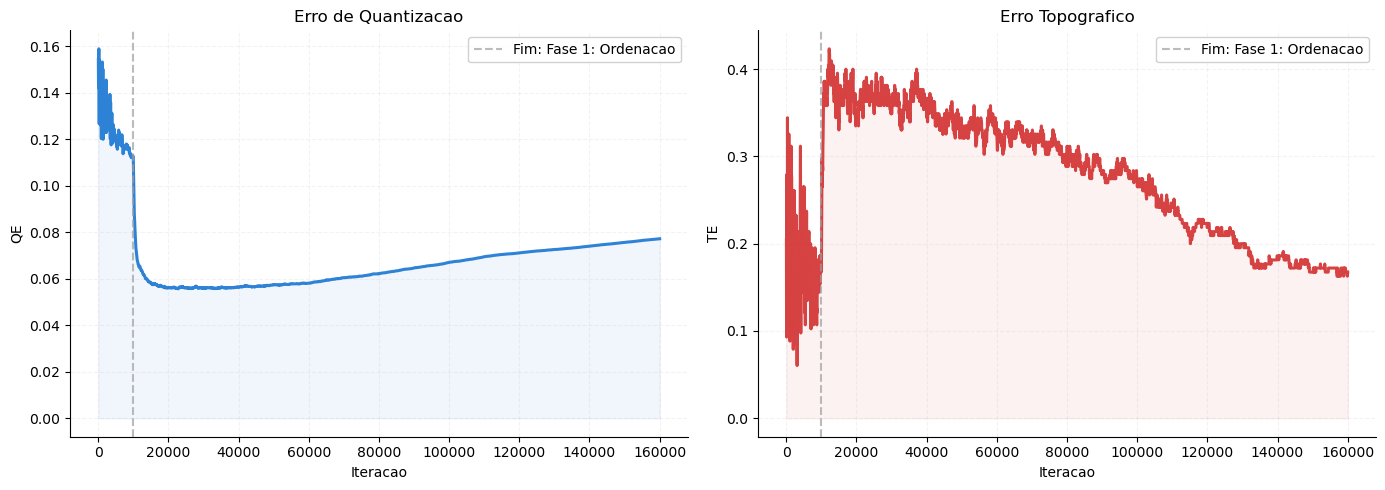

In [38]:
som.plot_training_history()

/tmp/ipykernel_25158/1018478641.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


<Axes: title={'center': 'U-Matrix'}>

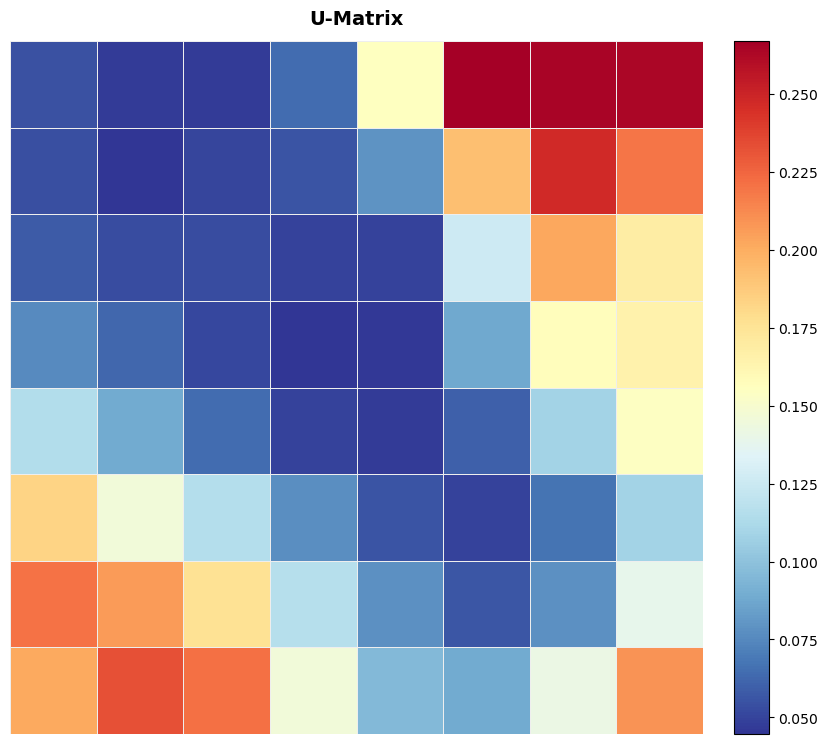

In [39]:
som.plot_umatrix()

/tmp/ipykernel_25158/1018478641.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


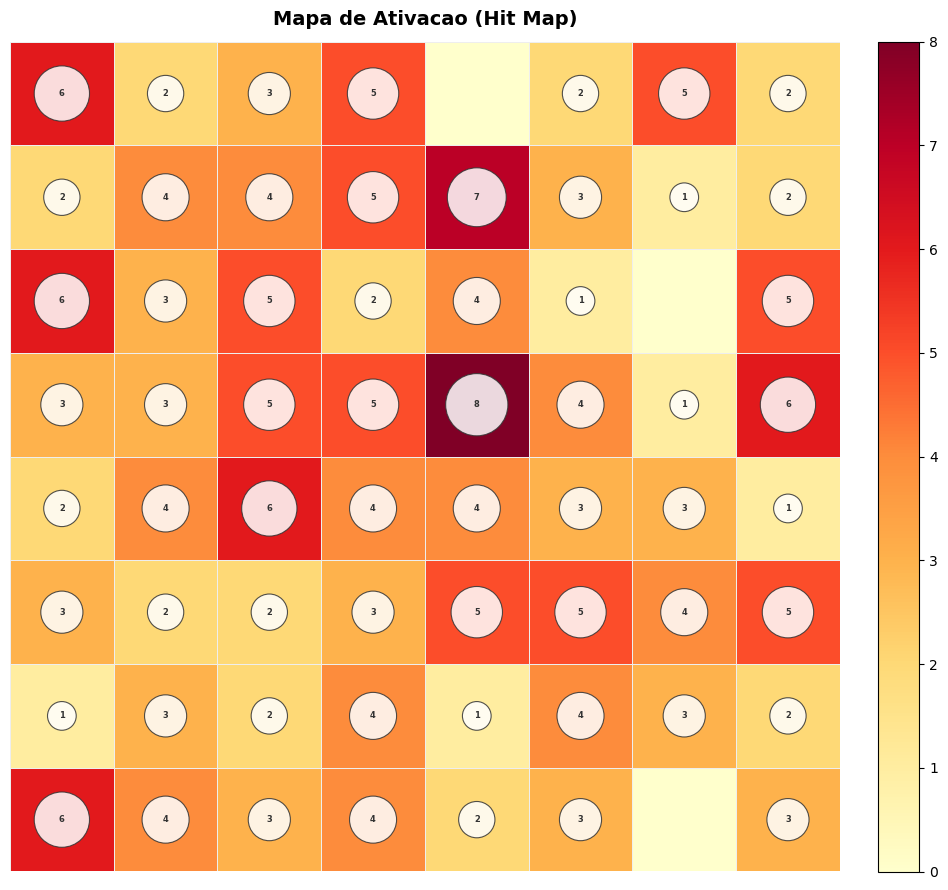

<Axes: title={'center': 'Mapa de Ativacao (Hit Map)'}>

In [40]:
som.plot_hit_map(X_tensor)

/tmp/ipykernel_25158/1018478641.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


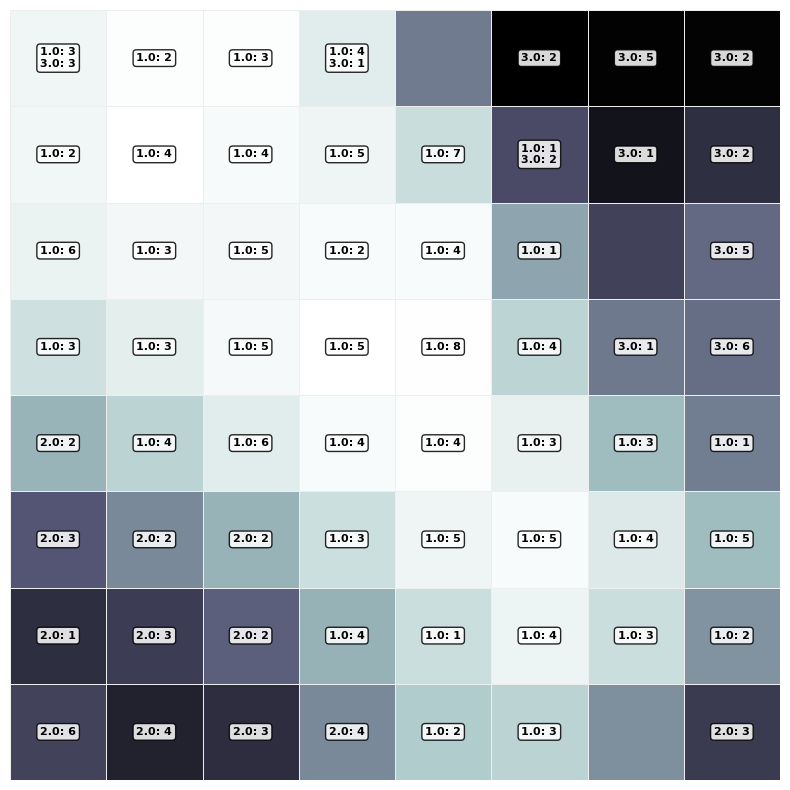

In [41]:
som.plot_label_counts(X_tensor, y)

Resposta

Neste primeiro experimento, comparamos diferentes tamanhos de grade para avaliar como a quantidade de neurônios influencia a organização do SOM. Para isso, mantemos a mesma topologia hexagonal, a mesma função de vizinhança gaussiana e a mesma taxa de aprendizado inicial. O raio inicial foi mantido proporcional ao tamanho do mapa, correspondendo a 50% do lado da grade, para tornar a comparação entre tamanhos mais justa. Foram testadas as configurações $5 \times 5$, $10 \times 10$ e $20 \times 20$. Dessa forma, conseguimos observar o impacto do tamanho do mapa sobre o erro de quantização, o erro topográfico e a estrutura visual da U-Matrix.

,configuracao,m,n,neuronios,topologia,vizinhanca,eta_inicio,sigma_inicio,QE_final,TE_final
0,5x5,5,5,25,hexagonal,gaussian,0.5,2.5,0.101822,0.041860
1,10x10,10,10,100,hexagonal,gaussian,0.5,5.0,0.076524,0.046512
2,20x20,20,20,400,hexagonal,gaussian,0.5,10.0,0.064822,0.023256


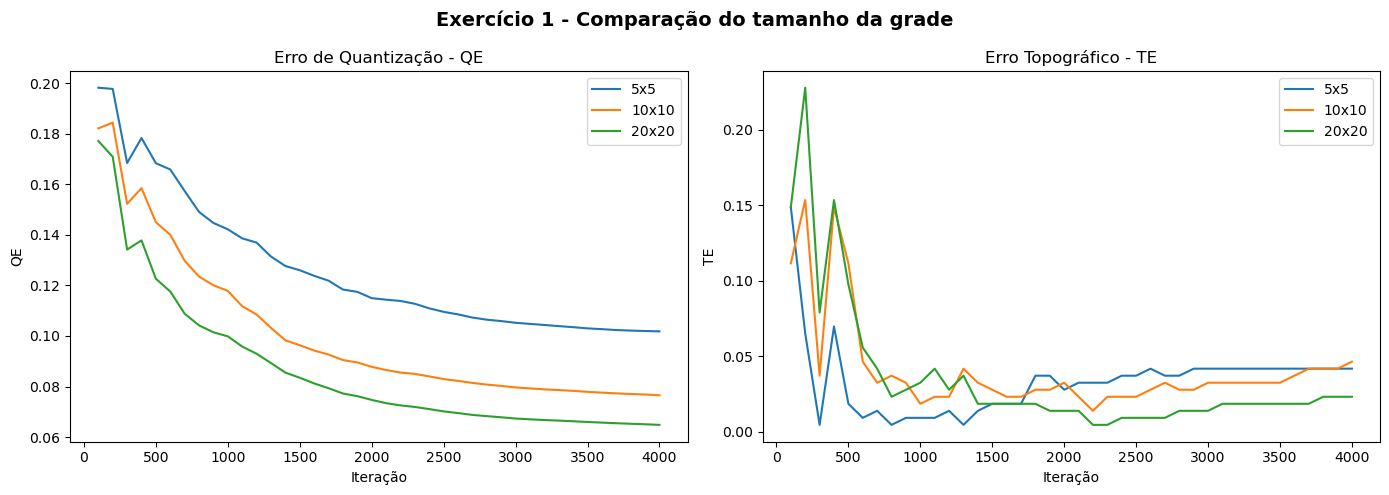

/tmp/ipykernel_25158/1018478641.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


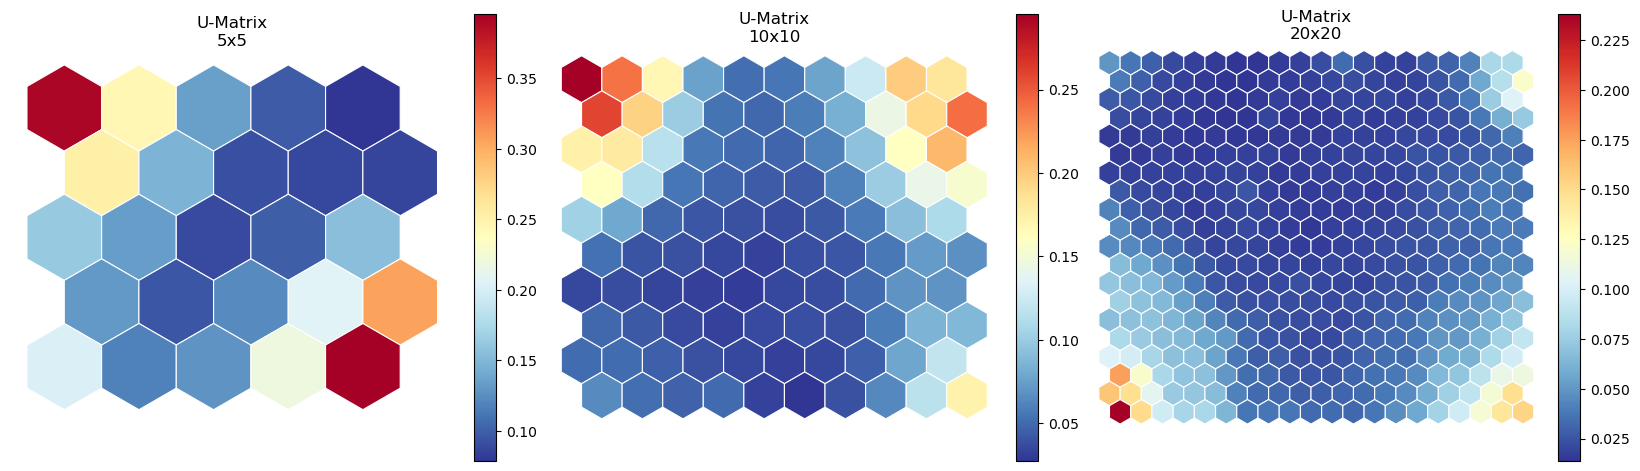

In [42]:
configs_grade = [
    {
        "nome": "5x5",
        "m": 5,
        "n": 5,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.5,
        "sigma1_start": 5 / 2,
    },
    {
        "nome": "10x10",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.5,
        "sigma1_start": 10 / 2,
    },
    {
        "nome": "20x20",
        "m": 20,
        "n": 20,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.5,
        "sigma1_start": 20 / 2,
    },
]

soms_grade, tabela_grade = rodar_experimentos(
    configs_grade,
    titulo="Exercício 1 - Comparação do tamanho da grade",
    mostrar_umatrix=True,
)

### Resposta — Exercício 1

**1) Qual o impacto no Erro de Quantização?**

Ao aumentar o tamanho da grade, aumentamos também a quantidade de neurônios disponíveis para representar os pacientes. Por isso, é esperado que o **Erro de Quantização (QE)** diminua, pois cada observação tende a ficar mais próxima do seu neurônio vencedor.

Nos resultados obtidos, isso aconteceu de forma clara:

- grade 5x5:   QE final  igual a **0,1018**;
- grade 10x10: QE final  igual a **0,0765**;
- grade 20x20: QE final  igual a **0,0648**.

Portanto, do ponto de vista do Erro de Quantização, a grade maior apresentou a melhor representação dos dados.

---
**2) E no Erro Topográfico?**

O **Erro Topográfico (TE)** apresentou um comportamento mais "oscilatório" durante o treinamento, principalmente nas primeiras iterações. Isso é esperado, pois o **TE** mede se a relação de vizinhança entre os dados está sendo preservada no mapa, e pequenas mudanças na posição dos BMUs podem alterar esse indicador ao longo do treinamento.

Os valores finais foram aproximadamente:

- grade $5 \times 5$: TE final igual a **0,0419**;
- grade $10 \times 10$: TE final igual a **0,0465**;
- grade $20 \times 20$: TE final igual a **0,0233**.

Assim, pelos indicadores finais, a grade $20 \times 20$ apresentou o menor erro topográfico. Isso indica que, neste experimento, aumentar a grade não prejudicou a preservação da topologia; pelo contrário, a grade maior conseguiu organizar melhor a vizinhança dos dados no mapa. No entanto, é importante observar que o TE teve oscilações durante o treinamento, então a análise não deve considerar apenas o menor valor final de forma isolada.

---

**3) Existe um limite em que aumentar a grade piora o modelo para este dataset?**

Sim, existe um limite prático. Mesmo que a grade 20x20 tenha apresentado o menor QE e o menor TE final, ela possui **400 neurônios**, enquanto a base tem apenas **215 observações**. Ou seja, há mais neurônios do que pacientes.

Nesse caso, muitos neurônios podem ficar vazios ou pouco utilizados. Isso pode até melhorar os indicadores numéricos, mas dificulta a interpretação do mapa, principalmente da U-Matrix, porque a grade fica mais detalhada do que o tamanho da base justifica.

Portanto, não escolheríamos a configuração apenas pelo menor QE ou menor TE. Para este dataset, a grade **10x10** parece uma escolha mais equilibrada, pois reduz bastante o erro em relação à grade 5x5, mantém uma boa organização visual e evita o excesso de neurônios da grade 20x20.

### Exercício 2: Taxa de Aprendizado Inicial ($\eta$)
Fixe uma topologia e varie apenas o $\eta_{start}$ da fase de ordenação (ex: `0.9`, `0.5`, e `0.05`).
* O que acontece se a taxa for muito alta? E muito baixa?
* Como isso afeta a estabilidade das curvas de erro?



Neste experimento, comparamos diferentes valores para a taxa de aprendizado inicial, mantendo fixos o tamanho da grade, a topologia e a função de vizinhança. O objetivo é observar como o valor inicial de $\eta$ influencia a velocidade de adaptação dos neurônios, a estabilidade do treinamento, o erro de quantização, o erro topográfico e a organização visual da U-Matrix.

,configuracao,m,n,neuronios,topologia,vizinhanca,eta_inicio,sigma_inicio,QE_final,TE_final
0,eta=0.90,10,10,100,hexagonal,gaussian,0.90,5.0,0.074165,0.079070
1,eta=0.50,10,10,100,hexagonal,gaussian,0.50,5.0,0.076524,0.046512
2,eta=0.05,10,10,100,hexagonal,gaussian,0.05,5.0,0.078720,0.083721


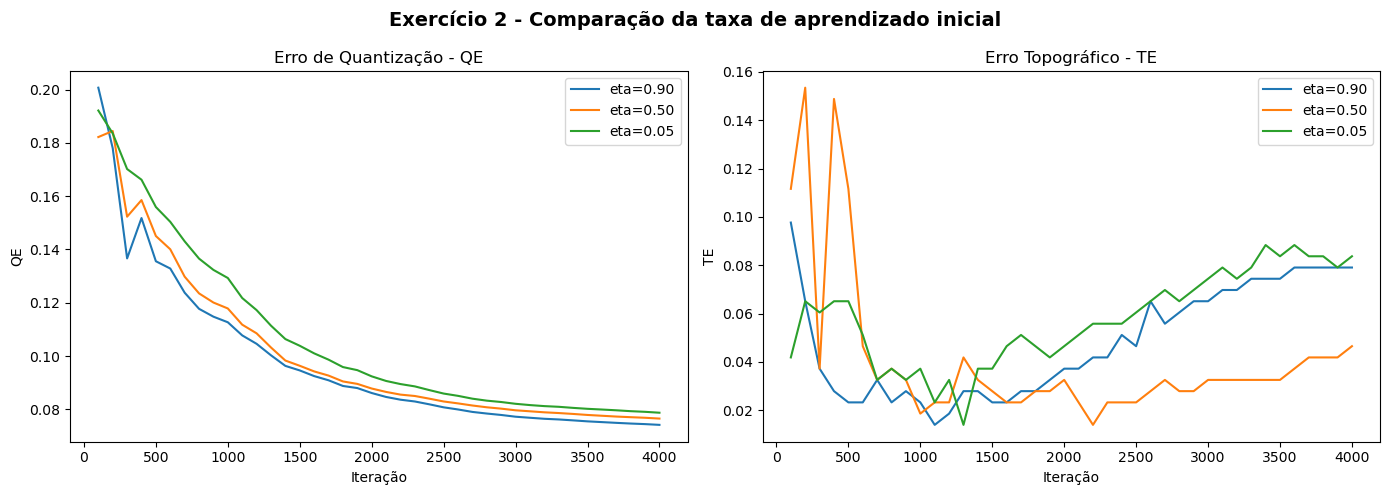

/tmp/ipykernel_25158/1018478641.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


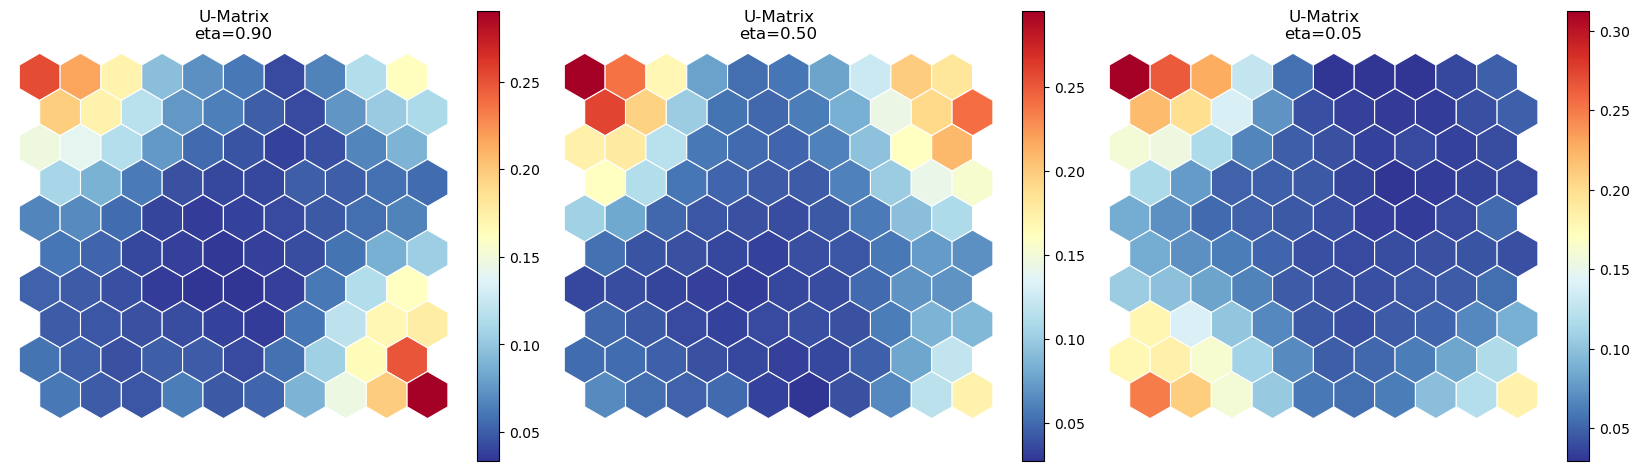

In [43]:
configs_eta = [
    {
        "nome": "eta=0.90",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.90,
        "sigma1_start": 10 / 2,
    },
    {
        "nome": "eta=0.50",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.50,
        "sigma1_start": 10 / 2,
    },
    {
        "nome": "eta=0.05",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.05,
        "sigma1_start": 10 / 2,
    },
]

soms_eta, tabela_eta = rodar_experimentos(
    configs_eta,
    titulo="Exercício 2 - Comparação da taxa de aprendizado inicial",
    mostrar_umatrix=True,
)

### Resposta — Exercício 2

**1) O que acontece se a taxa for muito alta?**

Quando a taxa de aprendizado inicial é muito alta, como no caso de `eta_start = 0.90`, os pesos dos neurônios são atualizados com passos maiores. Isso faz com que o mapa aprenda mais rápido no começo do treinamento, pois os protótipos se deslocam com maior intensidade em direção às observações apresentadas.

Nos resultados obtidos, esse comportamento aparece principalmente no **Erro de Quantização (QE)**. A configuração com `eta = 0.90` terminou com o menor QE final, aproximadamente **0,0742**, indicando que os neurônios ficaram, em média, mais próximos das observações. Além disso, a curva de QE para `eta = 0.90` fica abaixo das demais ao final do treinamento, mostrando que essa taxa alta favoreceu a aproximação dos dados pelos neurônios vencedores.

Por outro lado, uma taxa muito alta pode prejudicar a estabilidade topológica do mapa. Isso aparece no **Erro Topográfico (TE)**: apesar do bom resultado em QE, o `eta = 0.90` terminou com TE aproximadamente **0,0791**, valor maior do que o obtido com `eta = 0.50`. Isso indica que os neurônios até ficaram próximos dos dados, mas a organização das vizinhanças no mapa não foi a melhor.

Na U-Matrix do `eta = 0.90`, observamos regiões de separação mais fortes nas extremidades, principalmente nas bordas superior esquerda e inferior direita. Isso sugere possíveis fronteiras entre grupos, mas também indica que uma taxa alta pode gerar uma organização mais brusca, com regiões bem marcadas e uma estrutura topológica menos estável.

Assim, uma taxa alta pode melhorar a aproximação dos dados, mas não necessariamente produz a melhor organização topológica.

---

**2) E se for muito baixa?**

Quando a taxa de aprendizado inicial é muito baixa, como `eta_start = 0.05`, o SOM fica conservador demais. Os pesos mudam pouco a cada atualização, e o mapa demora mais para se organizar. Isso pode deixar o treinamento aparentemente mais suave, mas também pode impedir que os neurônios se ajustem de forma suficiente aos dados dentro do número de iterações utilizado.

Nos resultados, essa configuração apresentou o pior QE final, aproximadamente **0,0787**, e também o pior TE final, aproximadamente **0,0837**. Isso mostra que, para este dataset, uma taxa muito baixa não trouxe vantagem nem na representação dos dados, nem na preservação topológica.

A curva de QE para `eta = 0.05` fica acima das demais durante praticamente todo o treinamento, mostrando que a adaptação dos pesos foi mais lenta. Já no gráfico do TE, a curva também termina com valor elevado, indicando que o mapa não conseguiu preservar tão bem as relações de vizinhança entre as observações.

Na U-Matrix do `eta = 0.05`, ainda aparecem possíveis regiões de separação, mas a estrutura visual fica menos equilibrada. Há áreas de fronteira nas bordas e uma região central mais homogênea, mas a separação entre grupos parece menos consolidada do que na configuração intermediária. Assim, visualmente, essa taxa baixa sugere uma organização mais lenta e menos eficiente do mapa.

---

**3) Como isso afeta a estabilidade das curvas de erro?**

As curvas mostram que a taxa de aprendizado influencia tanto a velocidade de queda do erro quanto a estabilidade final do treinamento.

No caso do **Erro de Quantização (QE)**, as curvas aparecem mais organizadas e praticamente uma abaixo da outra. Isso ocorre porque o QE mede diretamente a distância média entre as observações e seus neurônios vencedores. Assim, quanto melhor os neurônios se aproximam dos dados, menor tende a ser esse erro. Nesse critério, `eta = 0.90` obteve o melhor resultado, seguido por `eta = 0.50` e depois por `eta = 0.05`.

No caso do **Erro Topográfico (TE)**, as curvas ficam mais embaralhadas e oscilam bastante. Isso é esperado, pois o TE é mais sensível à organização das vizinhanças no mapa. Pequenas mudanças na posição dos BMUs podem alterar bastante esse indicador, fazendo com que as curvas se cruzem e oscilem ao longo do treinamento. Por isso, o menor QE não implica necessariamente o menor TE.

A configuração intermediária, `eta = 0.50`, apresentou o melhor TE final, aproximadamente **0,0465**, indicando melhor preservação topológica. Além disso, sua U-Matrix parece mais equilibrada visualmente: ela apresenta uma região central mais homogênea e fronteiras mais organizadas nas bordas, sugerindo algo em torno de **2 a 3 regiões principais** no mapa. Essa leitura é coerente com a ideia de que uma taxa intermediária consegue ajustar os pesos sem provocar deslocamentos excessivamente bruscos.

Portanto, para este exercício, escolheríamos `eta_start = 0.50` como configuração mais equilibrada. Embora `eta = 0.90` tenha produzido o menor QE, o `eta = 0.50` apresentou melhor estabilidade topológica, menor TE final e uma U-Matrix visualmente mais organizada. Assim, ele parece ser a melhor escolha geral para este dataset.


### Exercício 3: Raio de Vizinhança ($\sigma$)
Varie o $\sigma_{start}$ (raio inicial). Teste um valor muito pequeno (ex: cobrindo apenas 10% do mapa) e um valor grande (cobrindo 80% do mapa).
* Qual a diferença prática na organização global do mapa (Topographic Error)?



Neste caso, comparamos diferentes valores para o raio de vizinhança inicial, mantendo fixos o tamanho da grade, a topologia, a função de vizinhança e a taxa de aprendizado inicial. O objetivo é observar como o valor inicial de $\sigma$ influencia a organização global do mapa, a especialização local dos neurônios, o erro de quantização, o erro topográfico e a estrutura visual da U-Matrix.

,configuracao,m,n,neuronios,topologia,vizinhanca,eta_inicio,sigma_inicio,QE_final,TE_final
0,sigma pequeno,10,10,100,hexagonal,gaussian,0.5,1.0,0.069455,0.097674
1,sigma médio,10,10,100,hexagonal,gaussian,0.5,5.0,0.076524,0.046512
2,sigma grande,10,10,100,hexagonal,gaussian,0.5,8.0,0.075589,0.060465


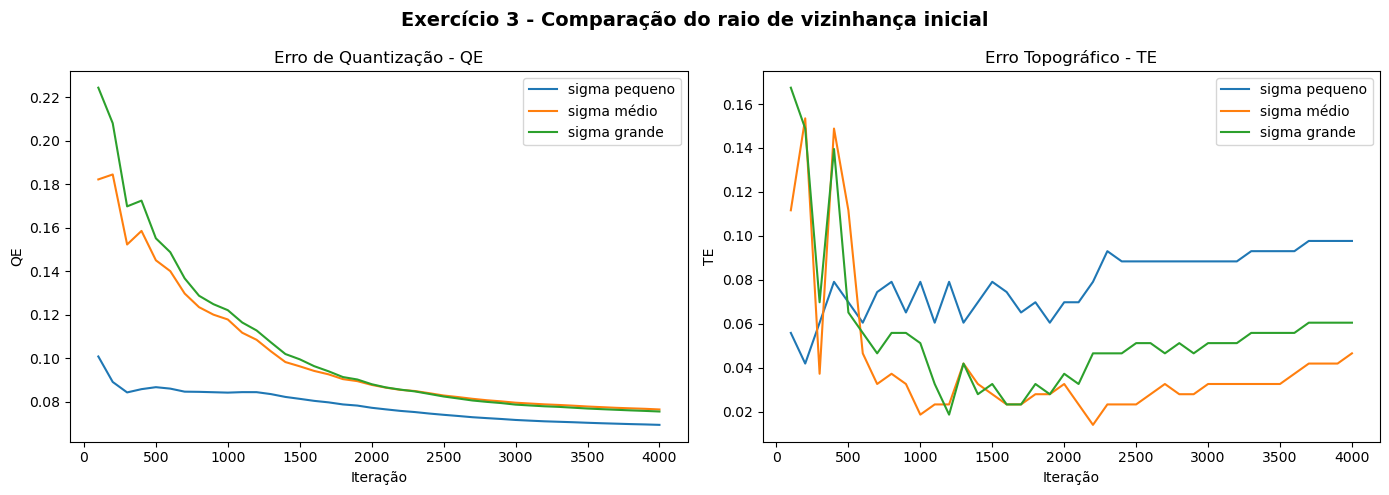

/tmp/ipykernel_25158/1018478641.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


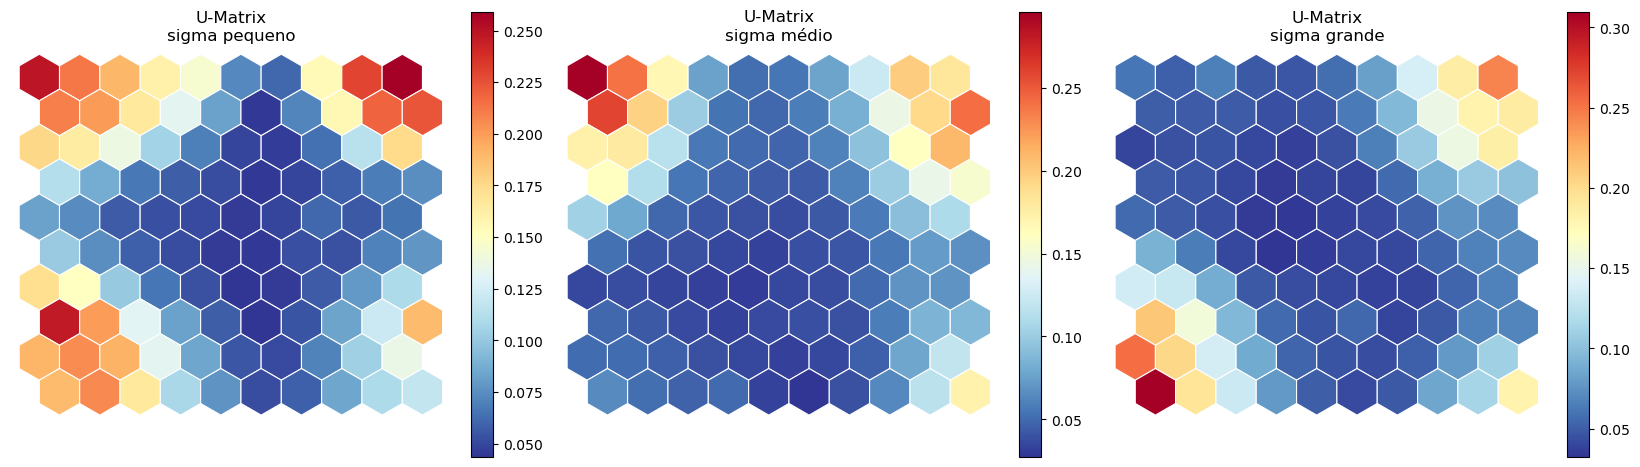

In [49]:
configs_sigma = [
    {
        "nome": "sigma pequeno",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.5,
        "sigma1_start": 1.0,
    },
    {
        "nome": "sigma médio",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.5,
        "sigma1_start": 5.0,
    },
    {
        "nome": "sigma grande",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.5,
        "sigma1_start": 8.0,
    },
]

soms_sigma, tabela_sigma = rodar_experimentos(
    configs_sigma,
    titulo="Exercício 3 - Comparação do raio de vizinhança inicial",
    mostrar_umatrix=True,
)

### Resposta — Exercício 3

**1) Qual é a diferença prática na organização global do mapa, especialmente no Erro Topográfico?**

O raio de vizinhança inicial, representado por `sigma_start`, controla quantos neurônios ao redor do neurônio vencedor também serão atualizados durante o treinamento. Portanto, ele influencia diretamente a organização global do mapa. Quando o valor de `sigma` é pequeno, o treinamento fica mais local desde o início. Quando o valor é maior, uma região maior do mapa é atualizada junto com o BMU, favorecendo uma ordenação mais global.

Nos resultados obtidos, o `sigma pequeno`, com `sigma = 1.0`, apresentou o menor Erro de Quantização, aproximadamente **0,0695**. Isso indica que os neurônios ficaram, em média, mais próximos das observações. No entanto, essa configuração apresentou o pior Erro Topográfico, aproximadamente **0,0977**. Portanto, apesar de representar bem os dados individualmente, o mapa não preservou tão bem a estrutura de vizinhança entre as observações.

Esse comportamento também aparece nas curvas. No gráfico do QE, a curva do `sigma pequeno` já começa mais baixa e permanece abaixo das demais durante praticamente todo o treinamento. Porém, no gráfico do TE, essa mesma configuração apresenta valores mais altos no final, mostrando que o ajuste local melhorou a aproximação dos dados, mas prejudicou a organização topológica global.

Com `sigma médio`, usando `sigma = 5.0`, tivemos o melhor equilíbrio. O QE final foi aproximadamente **0,0765**, um pouco maior do que no caso do `sigma pequeno`, mas o TE final foi o menor, aproximadamente **0,0465**. Isso indica que a vizinhança intermediária ajudou os neurônios a se organizarem melhor como conjunto, preservando melhor as relações de proximidade no mapa.

A U-Matrix do `sigma médio` também parece mais equilibrada visualmente. Ela apresenta uma região central mais homogênea e algumas regiões de maior distância nas bordas, sugerindo possíveis fronteiras entre grupos sem deixar o mapa excessivamente fragmentado. Visualmente, essa configuração sugere algo em torno de **2 a 3 regiões principais**, o que é coerente com a ideia de uma boa organização global.

Já com `sigma grande`, usando `sigma = 8.0`, o mapa apresentou QE final aproximadamente **0,0756** e TE final aproximadamente **0,0605**. Esse resultado foi melhor do que o `sigma pequeno` em termos de topologia, mas pior do que o `sigma médio`. Isso sugere que um raio muito grande ajuda na organização global inicial, mas pode suavizar demais o mapa, fazendo muitos neurônios se moverem juntos e atrasando a diferenciação local das regiões.

Na U-Matrix do `sigma grande`, observamos uma estrutura mais suavizada, com regiões de separação menos fragmentadas do que no `sigma pequeno`. Ainda assim, a organização não ficou tão equilibrada quanto no `sigma médio`. Assim, o `sigma grande` parece produzir um mapa mais globalmente organizado do que o `sigma pequeno`, mas com menor capacidade de refinamento local.

Portanto, neste experimento, o `sigma pequeno` favoreceu mais o ajuste local e reduziu o QE, mas prejudicou a preservação topológica. O `sigma grande` ajudou na organização global, mas suavizou demais a estrutura do mapa. Já o `sigma médio` apresentou o melhor equilíbrio entre representação dos dados e preservação topológica. Assim, para uma grade $10 \times 10$, usar um valor intermediário, como `sigma = 5.0`, parece ser a configuração mais adequada.


### Exercício 4: Topologia e Função de Vizinhança
Teste as topologias (`hexagonal` vs `rectangular`) e as funções de vizinhança (`gaussian` vs `bubble`). Observe especificamente o impacto gerando a **U-Matrix** para cada configuração.
* Qual combinação gera matrizes de distâncias com transições mais suaves?



Agora, testamos diferentes combinações entre a topologia do mapa e a função de vizinhança. A topologia define como os neurônios estão distribuídos na grade, enquanto a função de vizinhança define como os neurônios próximos ao BMU são atualizados. Assim, comparamos configurações hexagonais e retangulares, combinadas com vizinhanças gaussianas e bubble, para avaliar o impacto dessas escolhas no QE, no TE e na estrutura visual da U-Matrix.

,configuracao,m,n,neuronios,topologia,vizinhanca,eta_inicio,sigma_inicio,QE_final,TE_final
0,hexagonal + gaussian,10,10,100,hexagonal,gaussian,0.5,5.0,0.076524,0.046512
1,hexagonal + bubble,10,10,100,hexagonal,bubble,0.5,5.0,0.068827,0.102326
2,rectangular + gaussian,10,10,100,rectangular,gaussian,0.5,5.0,0.075407,0.195349
3,rectangular + bubble,10,10,100,rectangular,bubble,0.5,5.0,0.067754,0.237209


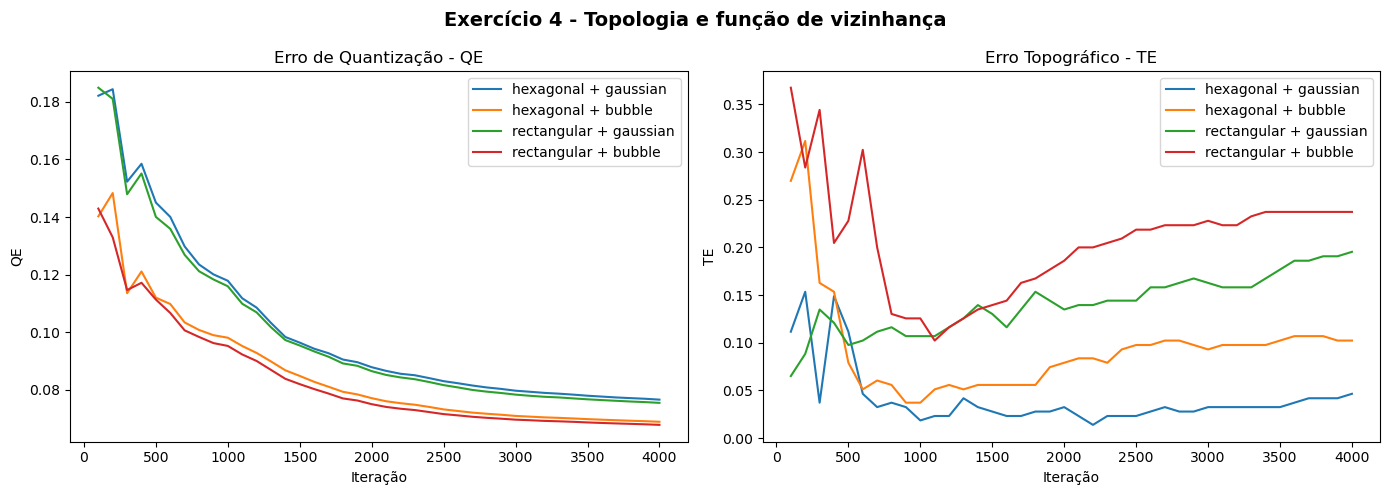

/tmp/ipykernel_25158/1018478641.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


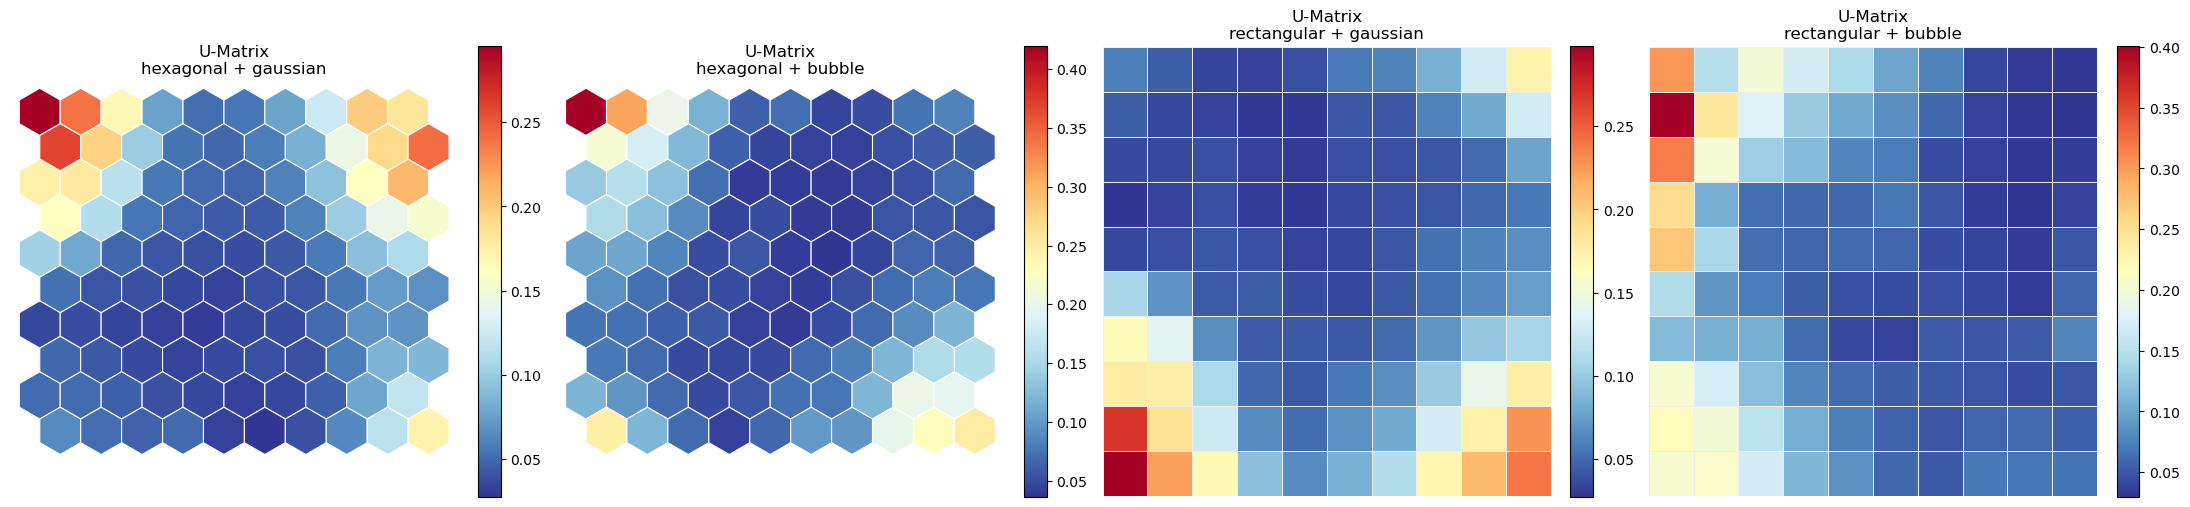

In [45]:
configs_topologia = [
    {
        "nome": "hexagonal + gaussian",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.5,
        "sigma1_start": 10 / 2,
    },
    {
        "nome": "hexagonal + bubble",
        "m": 10,
        "n": 10,
        "topology": "hexagonal",
        "neighborhood_fn": "bubble",
        "lr1_start": 0.5,
        "sigma1_start": 10 / 2,
    },
    {
        "nome": "rectangular + gaussian",
        "m": 10,
        "n": 10,
        "topology": "rectangular",
        "neighborhood_fn": "gaussian",
        "lr1_start": 0.5,
        "sigma1_start": 10 / 2,
    },
    {
        "nome": "rectangular + bubble",
        "m": 10,
        "n": 10,
        "topology": "rectangular",
        "neighborhood_fn": "bubble",
        "lr1_start": 0.5,
        "sigma1_start": 10 / 2,
    },
]

soms_topologia, tabela_topologia = rodar_experimentos(
    configs_topologia,
    titulo="Exercício 4 - Topologia e função de vizinhança",
    mostrar_umatrix=True,
)

### Resposta — Exercício 4

**1) Qual combinação gera matrizes de distâncias com transições mais suaves?**

 Comparamos não apenas valores numéricos, mas a própria forma como o mapa se organiza. A topologia define como os neurônios estão distribuídos na grade, enquanto a função de vizinhança define como os neurônios próximos ao BMU são atualizados durante o treinamento.

Pelos resultados obtidos, a combinação que apresentou a melhor organização topológica foi:

**topologia hexagonal + vizinhança gaussiana**

Essa configuração teve Erro Topográfico final aproximadamente igual a **0,0465**, o menor entre todas as combinações testadas. Isso indica que ela foi a que melhor preservou a relação de vizinhança entre os dados no mapa.

O ponto importante aqui é que a vizinhança gaussiana faz uma atualização mais suave. Os neurônios mais próximos do BMU recebem uma atualização maior, enquanto os mais distantes recebem uma atualização menor. Assim, o mapa vai se ajustando de forma gradual, sem mudanças muito bruscas entre regiões vizinhas.

Além disso, a topologia hexagonal costuma ajudar na organização visual, porque os neurônios ficam distribuídos de uma forma mais equilibrada no plano. Isso reduz um pouco aquele efeito artificial de linhas e colunas muito marcadas, que aparece mais naturalmente na grade retangular.

Quando olhamos para as U-Matrices, a configuração `hexagonal + gaussian` apresenta uma estrutura mais suave e mais fácil de interpretar. Existem regiões de maior distância, que podem indicar fronteiras entre grupos, mas essas transições não aparecem tão quebradas ou artificiais. Por isso, visualmente, essa configuração parece mais adequada para analisar possíveis agrupamentos.

Já as configurações com função `bubble` tiveram comportamento diferente. A função `bubble` atualiza todos os neurônios dentro de um certo raio de forma mais uniforme. Isso pode até reduzir o Erro de Quantização, como aconteceu com `hexagonal + bubble` e `rectangular + bubble`, mas tende a produzir uma organização topológica menos suave. Isso aparece nos valores de TE: `hexagonal + bubble` terminou com TE aproximadamente **0,1023**, enquanto `rectangular + bubble` terminou com TE aproximadamente **0,2372**.

As topologias retangulares também não foram tão boas em termos de preservação topológica. Mesmo com vizinhança gaussiana, a configuração `rectangular + gaussian` terminou com TE aproximadamente **0,1953**, bem acima da configuração hexagonal com gaussiana. Isso sugere que, para este conjunto de dados, a estrutura hexagonal foi mais adequada para organizar os neurônios no mapa.

Portanto, apesar de algumas configurações com `bubble` terem apresentado menor QE, elas não foram as melhores para preservar a estrutura do mapa. Como o objetivo do SOM não é apenas aproximar os dados, mas também manter uma organização topológica interpretável, a escolha mais equilibrada neste exercício foi:

**topologia hexagonal + vizinhança gaussiana**

Essa combinação apresentou o melhor TE, uma U-Matrix mais suave e uma estrutura visual mais coerente para interpretação dos grupos.

---
## PARTE 2: Modelo Final e Análise Qualitativa

### Exercício 5: Configuração Otimizada e Treinamento Final
Com base nas descobertas dos experimentos anteriores, defina a sua **melhor configuração** de hiperparâmetros.
1. Inicialize e treine o SOM definitivo com esses parâmetros.
2. Aplique o `K-Means` sobre os pesos dos neurônios deste SOM, forçando `K=3` (pois sabemos que existem 3 diagnósticos possíveis para a tireoide).



In [ ]:
# Configuração final escolhida
# Justificativa:
# - 10x10: grade intermediária, suficiente para representar os dados sem ficar excessivamente esparsa.
# - Hexagonal: melhor noção de vizinhança no plano.
# - Gaussian: atualização suave dos vizinhos.
# - eta=0.5 e sigma=max(m,n)/2: bons valores para ordenação global.

res_final = treinar_som_config(
    nome="SOM final",
    m=10,
    n=10,
    topology="hexagonal",
    neighborhood_fn="gaussian",
    init_method="pca",
    lr1_start=0.5,
    sigma1_start=5,
    fase1_iter=1000,
    fase2_iter=3000,
    eval_every=100,
    verbose=True,
)

som_final = res_final["som"]

print("Resultados finais do SOM:")
print(f"QE final: {res_final['QE_final']:.4f}")
print(f"TE final: {res_final['TE_final']:.4f}")

# K-Means nos pesos dos neurônios
kmeans_final, cluster_neuronio_final, cluster_amostra_final, bmus_final = aplicar_kmeans_som(
    som_final,
    n_clusters=3,
    random_state=42,
)

print("\nQuantidade de neurônios em cada cluster:")
print(pd.Series(cluster_neuronio_final).value_counts().sort_index())

print("\nQuantidade de pacientes em cada cluster:")
print(pd.Series(cluster_amostra_final).value_counts().sort_index())

SOM final | Fase 1: Ordenação:   0%|          | 0/1000 [00:00<?, ?it/s]

SOM final | Fase 2: Ajuste fino:   0%|          | 0/3000 [00:00<?, ?it/s]

Resultados finais do SOM:
QE final: 0.0765
TE final: 0.0465

Quantidade de neurônios em cada cluster:
0    10
1    83
2     7
Name: count, dtype: int64

Quantidade de pacientes em cada cluster:
0     24
1    167
2     24
Name: count, dtype: int64


### Resposta — Exercício 5

**1) Inicialização e treinamento do SOM definitivo**

Com base nos testes anteriores, a configuração final escolhida foi uma grade **10x10**, com **topologia hexagonal**, função de vizinhança **gaussian**, inicialização por **PCA**, `eta_start = 0.5` e `sigma_start = 5`.

Essa escolha foi feita porque ela apresentou um bom equilíbrio entre representação dos dados, preservação topológica e interpretabilidade visual. A grade 5x5 era pequena demais e poderia comprimir observações diferentes em poucos neurônios. Já a grade 20x20 tinha neurônios demais para uma base com 215 pacientes, o que poderia gerar muitos neurônios vazios ou pouco utilizados.

Além disso, nos testes anteriores, a combinação **hexagonal + gaussian** apresentou o menor Erro Topográfico entre as combinações de topologia e vizinhança, indicando melhor preservação da organização espacial do mapa.

No treinamento final, os resultados foram:

- **Erro de Quantização final:** aproximadamente **0,0765**;
- **Erro Topográfico final:** aproximadamente **0,0465**.

Esses valores indicam que o SOM conseguiu representar os dados de forma razoável, mantendo uma boa organização topológica.

---

**2) Aplicação do K-Means sobre os pesos dos neurônios**

Depois do treinamento do SOM, foi aplicado o **K-Means com K = 3** sobre os pesos dos neurônios, e não diretamente sobre os pacientes. Isso segue a ideia do notebook de aula: primeiro o SOM organiza os dados em uma malha topológica; depois, o K-Means agrupa os neurônios dessa malha em regiões maiores.

A quantidade de neurônios em cada cluster foi:

- cluster 0: **10 neurônios**;
- cluster 1: **83 neurônios**;
- cluster 2: **7 neurônios**.

Já a quantidade de pacientes associados a cada cluster foi:

- cluster 0: **24 pacientes**;
- cluster 1: **167 pacientes**;
- cluster 2: **24 pacientes**.

Assim, o cluster 1 concentrou a maior parte dos pacientes, enquanto os clusters 0 e 2 ficaram menores. Isso sugere que o SOM encontrou um grupo principal de pacientes e dois grupos menores, possivelmente associados a perfis mais específicos dentro da base.

Portanto, a configuração final escolhida parece adequada para este dataset, pois combina uma malha interpretável com uma etapa posterior de agrupamento dos neurônios em três regiões principais.

### Exercício 6: Análise Qualitativa e Pureza

Agora faça uma avaliação profunda dos resultados obtidos pela melhor configuração:
1. Plote a **U-Matrix**, os **Planos de Componentes** (para investigar quais hormônios influenciam cada área), e o **Mapa de Clusters** (com as fronteiras obtidas pelo K-Means e os rótulos 1.0, 2.0 e 3.0 dos pacientes reais).
2. Construa uma Tabela de Contingência (comparando os 3 clusters do SOM contra as 3 classes reais do dataset).
3. Calcule a **Pureza** de cada cluster e a pureza global.
4. **Responda:** Quais classes de tireoide são bem separadas pelo SOM? Quais se confundem mais? Olhando para os Planos de Componentes, quais hormônios são os maiores responsáveis por separar o Hipertireoidismo do Hipotireoidismo?



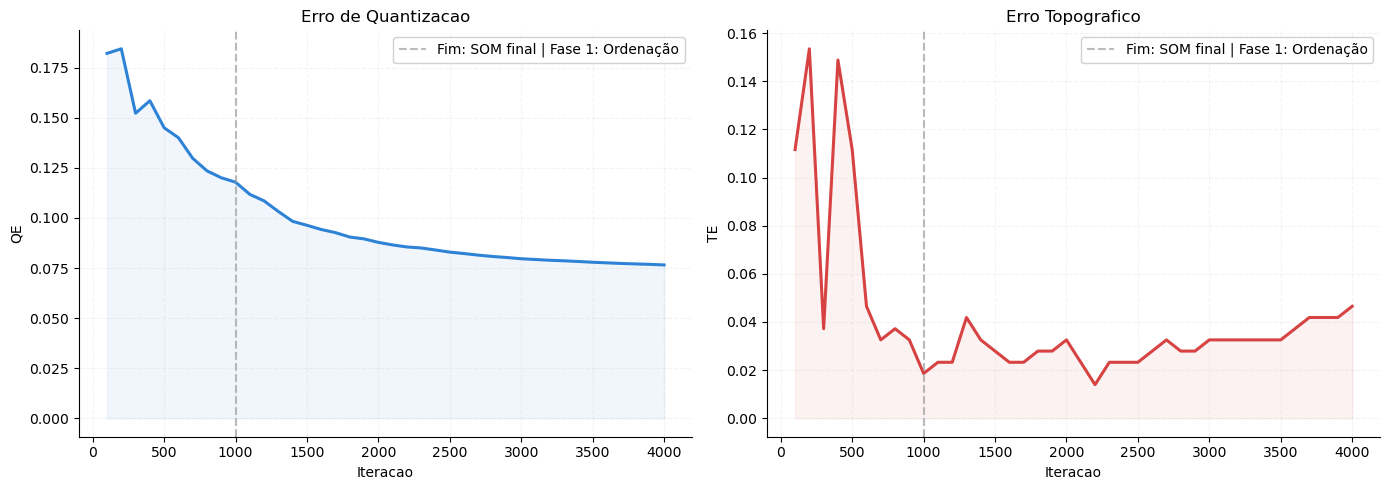

/tmp/ipykernel_25158/1018478641.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


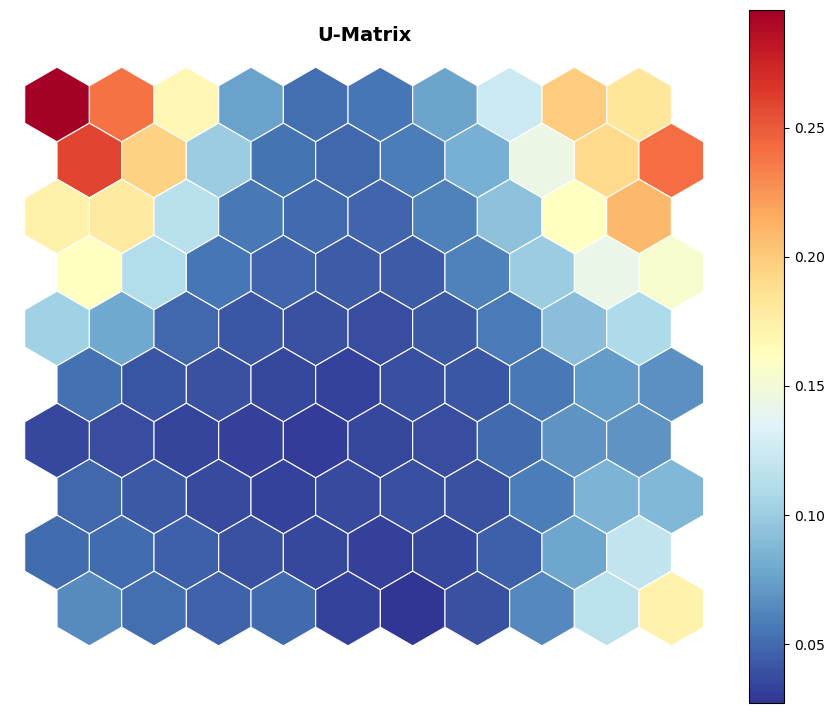

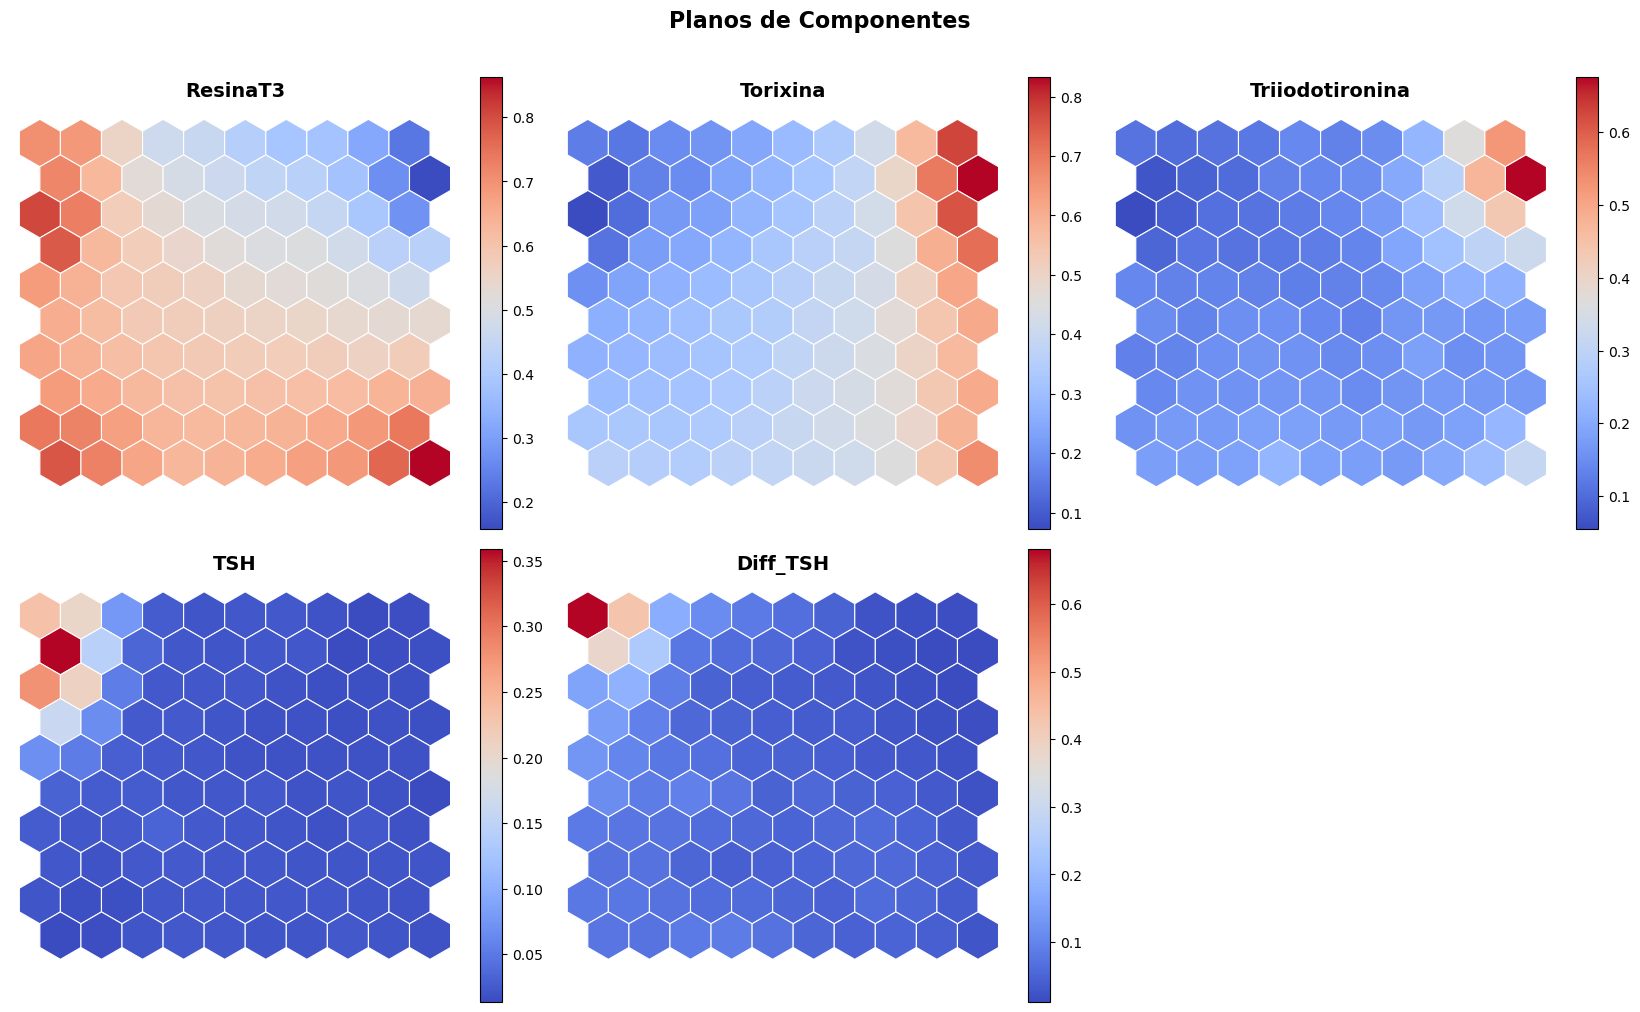

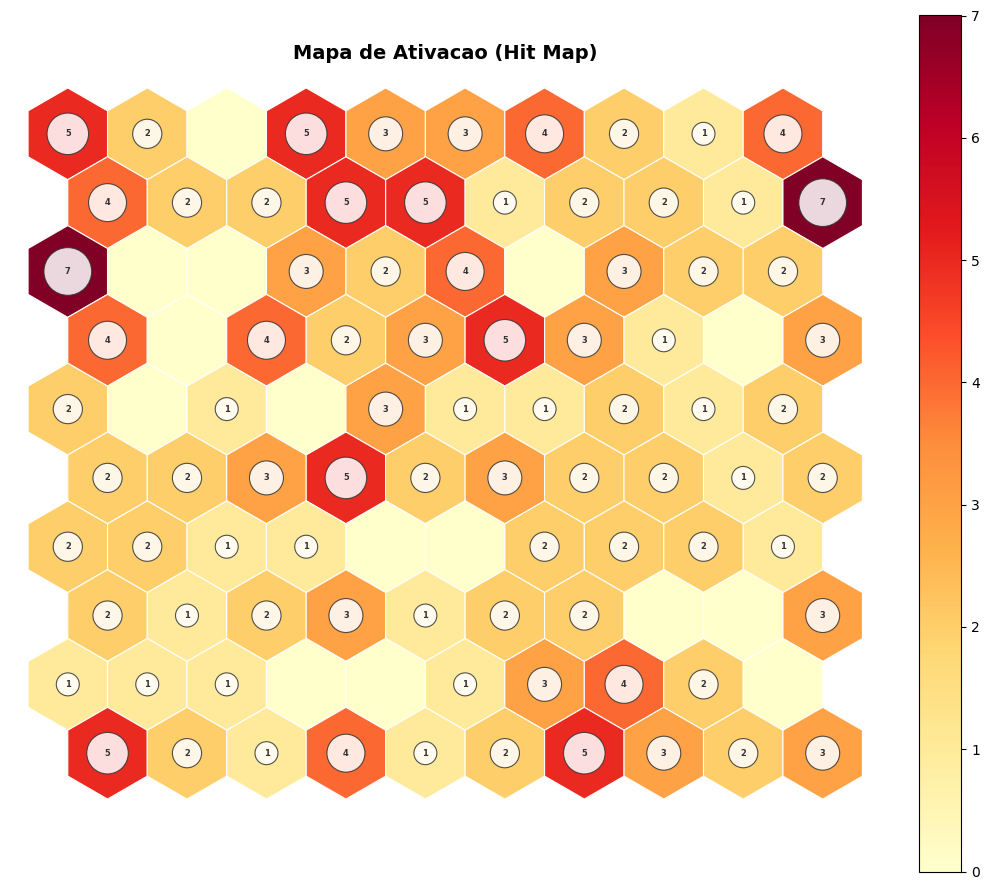

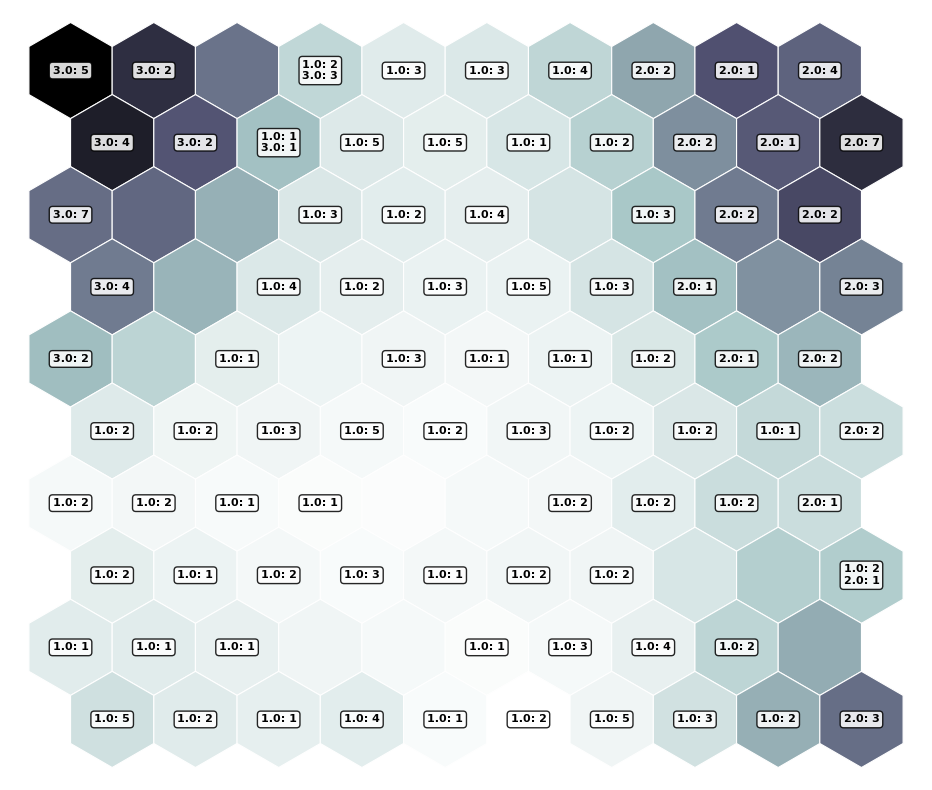

/tmp/ipykernel_25158/1018478641.py:463: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cl_cmap = plt.cm.get_cmap('Set2', n_cl)


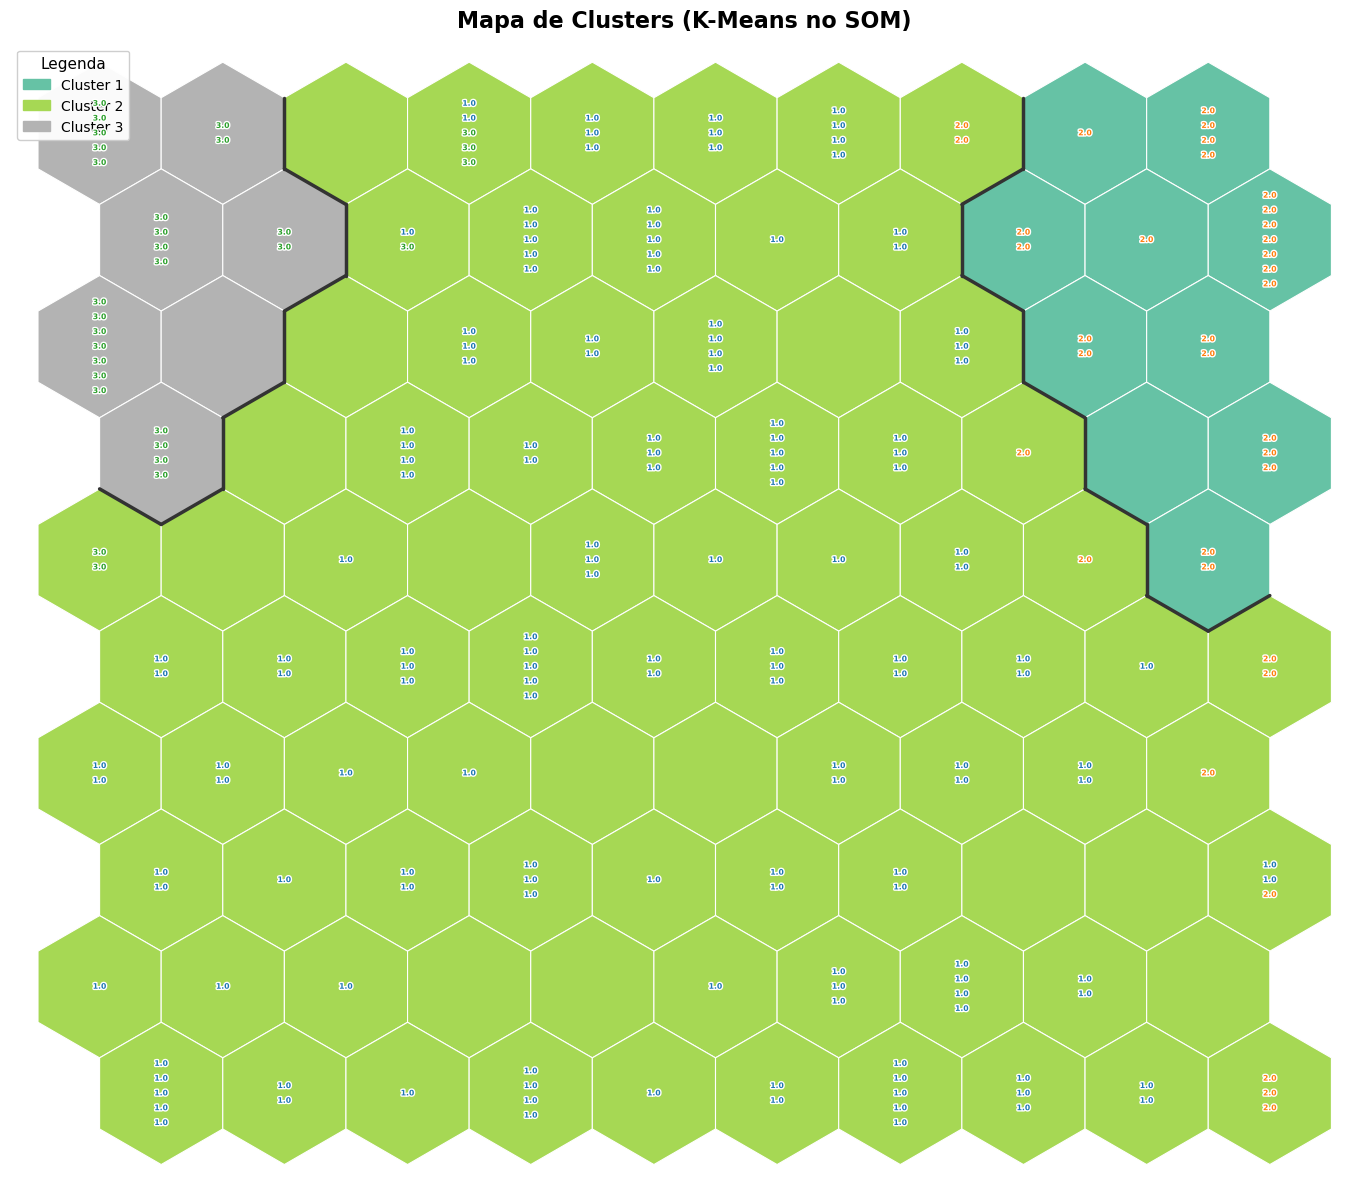

Cluster SOM,Cluster 1,Cluster 2,Cluster 3
Classe real,,,
1.0,0,150,0
2.0,24,11,0
3.0,0,6,24


,classe dominante,n_amostras,pureza
Cluster SOM,,,
Cluster 1,2.0,24,1.0000
Cluster 2,1.0,167,0.8982
Cluster 3,3.0,24,1.0000


Pureza global: 0.9209


,ResinaT3,Torixina,Triiodotironina,TSH,Diff_TSH
cluster_som,,,,,
Cluster 1,86.708,18.858,4.954,0.987,-0.033
Cluster 2,110.653,9.434,1.786,1.300,2.511
Cluster 3,125.125,3.329,0.983,15.767,20.179


,ResinaT3,Torixina,Triiodotironina,TSH,Diff_TSH,target,BMU,cluster_som
0,107.0,10.1,2.2,0.9,2.7,1.0,36,Cluster 2
1,113.0,9.9,3.1,2.0,5.9,1.0,93,Cluster 2
2,127.0,12.9,2.4,1.4,0.6,1.0,98,Cluster 2
3,109.0,5.3,1.6,1.4,1.5,1.0,23,Cluster 2
4,105.0,7.3,1.5,1.5,-0.1,1.0,24,Cluster 2


In [47]:
# 1) Visualizações principais
som_final.plot_training_history()
som_final.plot_umatrix()
som_final.plot_component_planes(feature_names=features)
som_final.plot_hit_map(X_tensor)
som_final.plot_label_counts(X_tensor, y_labels)

# Mapa de clusters com rótulos reais dos pacientes
cores_classes = {
    "1.0": "tab:blue",
    "2.0": "tab:orange",
    "3.0": "tab:green",
}

som_final.plot_cluster_map(
    cluster_neuronio_final,
    data=X_tensor,
    labels=y_labels,
    colors_dict=cores_classes,
    show_boundaries=True,
)

# 2) Tabela de contingência e pureza
df_comp_final, tabela_cont_final, pureza_final = tabela_contingencia_pureza(
    cluster_amostra_final,
    y,
)

# 3) Perfil médio das variáveis originais por cluster
perfil_final = perfil_por_cluster(cluster_amostra_final)

# 4) Tabela auxiliar com cada paciente, classe real, BMU e cluster
df_resultado_final = df_thyroid.copy()
df_resultado_final["BMU"] = bmus_final
df_resultado_final["cluster_som"] = [f"Cluster {c + 1}" for c in cluster_amostra_final]

display(df_resultado_final.head())


### Resposta — Exercício 6

**1) U-Matrix, planos de componentes e mapa de clusters**

Nesta etapa, analisamos o SOM final de forma mais qualitativa, olhando não apenas para os erros numéricos, mas também para a estrutura visual formada no mapa. A ideia aqui é entender se os grupos encontrados fazem sentido em relação às variáveis clínicas da base e se existe alguma correspondência com as três classes reais de diagnóstico da tireoide.

Primeiro, olhamos para as curvas de treinamento, vemos que o **Erro de Quantização (QE)** caiu de forma bem clara ao longo das iterações. Isso indica que os neurônios foram se aproximando progressivamente dos dados, melhorando a representação dos pacientes no mapa. Já o **Erro Topográfico (TE)** apresentou mais oscilações, principalmente no começo do treinamento, o que é esperado, porque essa métrica é mais sensível à posição relativa dos BMUs. Mesmo assim, depois das primeiras iterações, o TE ficou em uma faixa mais estável, terminando em um valor baixo, aproximadamente **0,0465**. Então, no geral, o treinamento conseguiu reduzir o erro de representação sem destruir a organização topológica do mapa.

Na **U-Matrix**, observamos regiões mais escuras no centro e na parte inferior do mapa, indicando áreas mais homogêneas, onde os neurônios vizinhos são parecidos entre si. Por outro lado, aparecem regiões mais claras e avermelhadas principalmente nas bordas, especialmente na parte superior esquerda, na região direita e em alguns pontos inferiores. Essas regiões de maior distância funcionam como possíveis fronteiras entre grupos. Isso sugere que o mapa não ficou completamente misturado; pelo contrário, ele formou regiões com certa separação visual.

Os **planos de componentes** ajudam a entender melhor o que cada região do mapa representa. O plano da `ResinaT3` mostra uma variação bem marcada ao longo da grade, com valores mais altos em algumas regiões inferiores e laterais. Já `Torixina` e `Triiodotironina` aparecem com valores mais elevados principalmente na região direita/superior do mapa, indicando uma área associada a pacientes com níveis mais altos desses hormônios. Por outro lado, `TSH` e `Diff_TSH` se destacam fortemente na região superior esquerda, mostrando que essa parte do mapa concentra pacientes com valores muito elevados dessas variáveis.

Esse padrão é importante, porque a separação entre os perfis clínicos parece estar muito ligada ao contraste entre hormônios tireoidianos e TSH. De um lado, temos regiões com `Torixina` e `Triiodotironina` mais altas e `TSH` baixo. De outro, temos regiões com `TSH` e `Diff_TSH` muito altos e `Torixina`/`Triiodotironina` baixos. Essa diferença é justamente o que ajuda o SOM a separar perfis associados ao hipertireoidismo e ao hipotireoidismo.

O **Hit Map** mostra que os pacientes não ficaram todos concentrados em poucos neurônios. Há uma boa distribuição pela malha, embora alguns neurônios recebam mais pacientes do que outros. Isso é natural, pois algumas regiões representam perfis mais comuns da base. O mapa de rótulos também mostra que a classe `1.0` aparece espalhada principalmente pela região mais central e dominante do mapa, enquanto as classes `2.0` e `3.0` aparecem mais associadas a regiões específicas.

No **mapa de clusters com K-Means**, a divisão ficou bem interpretável. O Cluster 2 ocupa a maior parte da malha, principalmente a região central e inferior, enquanto o Cluster 1 aparece mais à direita e o Cluster 3 aparece mais na região superior esquerda. Isso combina com o que vimos nos planos de componentes: a região superior esquerda tem valores altos de `TSH` e `Diff_TSH`, enquanto a região direita está mais ligada a valores altos de `Torixina` e `Triiodotironina`.

---

**2) Tabela de contingência**

A tabela de contingência compara os clusters encontrados pelo SOM/K-Means com as classes reais dos pacientes. Os resultados foram:

- a classe real `1.0` ficou totalmente concentrada no **Cluster 2**, com **150 pacientes**;
- a classe real `2.0` ficou principalmente no **Cluster 1**, com **24 pacientes**, mas teve **11 pacientes** no Cluster 2;
- a classe real `3.0` ficou principalmente no **Cluster 3**, com **24 pacientes**, mas teve **6 pacientes** no Cluster 2.

Esse resultado mostra que a classe `1.0` foi muito bem capturada pelo Cluster 2, sem pacientes dela aparecendo nos outros clusters. Já as classes `2.0` e `3.0` também foram bem separadas em seus clusters principais, mas parte delas acabou sendo absorvida pelo Cluster 2. Isso faz sentido, porque o Cluster 2 é o maior grupo e representa uma região mais central/intermediária do mapa.

Um ponto interessante é que praticamente não houve confusão direta entre as classes `2.0` e `3.0`. A confusão maior aconteceu entre cada uma dessas classes e a classe `1.0`, representada pelo Cluster 2. Isso sugere que o SOM conseguiu separar bem os perfis extremos, mas alguns pacientes com características menos evidentes acabam ficando próximos da região central.

---

**3) Pureza**

A pureza global obtida foi aproximadamente:

$$
\text{pureza} = 0{,}9209
$$

Esse valor é alto, pois está bem próximo de 1. Isso indica que a maior parte dos pacientes foi agrupada em clusters com uma classe dominante.

Analisando por cluster, temos:

- **Cluster 1:** pureza igual a **1,0000**, pois os 24 pacientes pertencem à classe `2.0`;
- **Cluster 2:** pureza aproximadamente igual a **0,8982**, pois 150 dos 167 pacientes pertencem à classe `1.0`;
- **Cluster 3:** pureza igual a **1,0000**, pois os 24 pacientes pertencem à classe `3.0`.

Assim, os Clusters 1 e 3 ficaram muito bem definidos, enquanto o Cluster 2 concentrou a maior parte dos pacientes e também recebeu os casos que ficaram mais próximos de uma região intermediária. Mesmo assim, como a classe dominante do Cluster 2 é muito forte, a pureza global ficou alta.

O ponto mais importante é que o SOM foi treinado de forma não supervisionada, ou seja, sem usar a variável `target` durante o treinamento. Mesmo assim, os grupos formados apresentaram uma correspondência muito boa com as classes reais. Isso mostra que as variáveis hormonais possuem uma estrutura interna forte o suficiente para o SOM organizar os pacientes em regiões compatíveis com os diagnósticos.

---

**4) Interpretação qualitativa dos clusters**

A partir das médias dos atributos em cada cluster, conseguimos interpretar melhor o significado clínico das regiões encontradas.

O **Cluster 1** apresentou média de `Torixina` igual a **18,858** e média de `Triiodotironina` igual a **4,954**, valores bem mais altos do que os observados nos outros clusters. Ao mesmo tempo, apresentou `TSH` médio igual a **0,987** e `Diff_TSH` próximo de zero. Esse perfil está associado principalmente à classe real `2.0`. Portanto, esse cluster representa pacientes com maior concentração dos hormônios tireoidianos, sendo compatível com um perfil de hipertireoidismo.

O **Cluster 2** concentrou a maior parte dos pacientes da classe real `1.0`. Ele apresentou valores intermediários nas variáveis: `ResinaT3` média de **110,653**, `Torixina` média de **9,434**, `Triiodotironina` média de **1,786**, `TSH` médio de **1,300** e `Diff_TSH` médio de **2,511**. Esse cluster funciona como uma região central da base, representando o perfil mais comum ou mais próximo da normalidade. Por isso, ele também acabou absorvendo alguns pacientes das classes `2.0` e `3.0`, principalmente aqueles que provavelmente não estavam tão distantes do padrão intermediário.

O **Cluster 3** apresentou um comportamento bem diferente. Ele teve `TSH` médio igual a **15,767** e `Diff_TSH` médio igual a **20,179**, valores muito superiores aos dos outros clusters. Ao mesmo tempo, apresentou `Torixina` média de **3,329** e `Triiodotironina` média de **0,983**, ou seja, valores baixos desses hormônios. Esse padrão está associado principalmente à classe real `3.0`, indicando um perfil compatível com hipotireoidismo.

Dessa forma, as classes que ficaram mais bem separadas foram as classes `2.0` e `3.0`, principalmente porque elas possuem assinaturas hormonais bem diferentes. A classe `2.0` aparece ligada a maiores valores de `Torixina` e `Triiodotironina`, enquanto a classe `3.0` aparece ligada a valores muito altos de `TSH` e `Diff_TSH`. Já a classe `1.0` funciona como um grupo central/intermediário, sendo bem representada pelo Cluster 2, mas também servindo como região de aproximação para alguns pacientes das outras classes.

Olhando para os planos de componentes, os hormônios que mais ajudam a separar o hipertireoidismo do hipotireoidismo são principalmente `TSH`, `Diff_TSH`, `Torixina` e `Triiodotironina`. O `TSH` e o `Diff_TSH` se destacam muito na região associada ao Cluster 3, enquanto `Torixina` e `Triiodotironina` aparecem mais fortes na região associada ao Cluster 1. A `ResinaT3` também contribui para a organização do mapa, mas a separação mais forte entre os extremos parece vir do contraste entre `TSH`/`Diff_TSH` e os hormônios tireoidianos.

Portanto, os resultados mostram que o SOM conseguiu capturar uma estrutura clínica relevante nos dados. O mapa separou bem os perfis extremos, manteve um grupo central dominante e apresentou uma pureza global alta. Isso indica que a configuração escolhida foi adequada tanto numericamente quanto qualitativamente, pois os clusters encontrados fazem sentido quando analisamos os planos de componentes e a distribuição real dos diagnósticos.


### Exercício 7: Explorando o agrupamento de forma manual.

Repita o processo realizado nos dois últimos exercícios, desta vez gerando **manualmente** os grupos gerados com base na distância entre neurônios. Responda:

1. Quantos grupos você consegue observar?
2. Quais são as características de cada um desses grupos?

Quantidade de grupos manuais: 3

Quantidade de neurônios por grupo manual:
0    14
1    76
2    10
Name: count, dtype: int64

Quantidade de pacientes por grupo manual:
0     32
1    157
2     26
Name: count, dtype: int64


/tmp/ipykernel_25158/1018478641.py:463: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cl_cmap = plt.cm.get_cmap('Set2', n_cl)


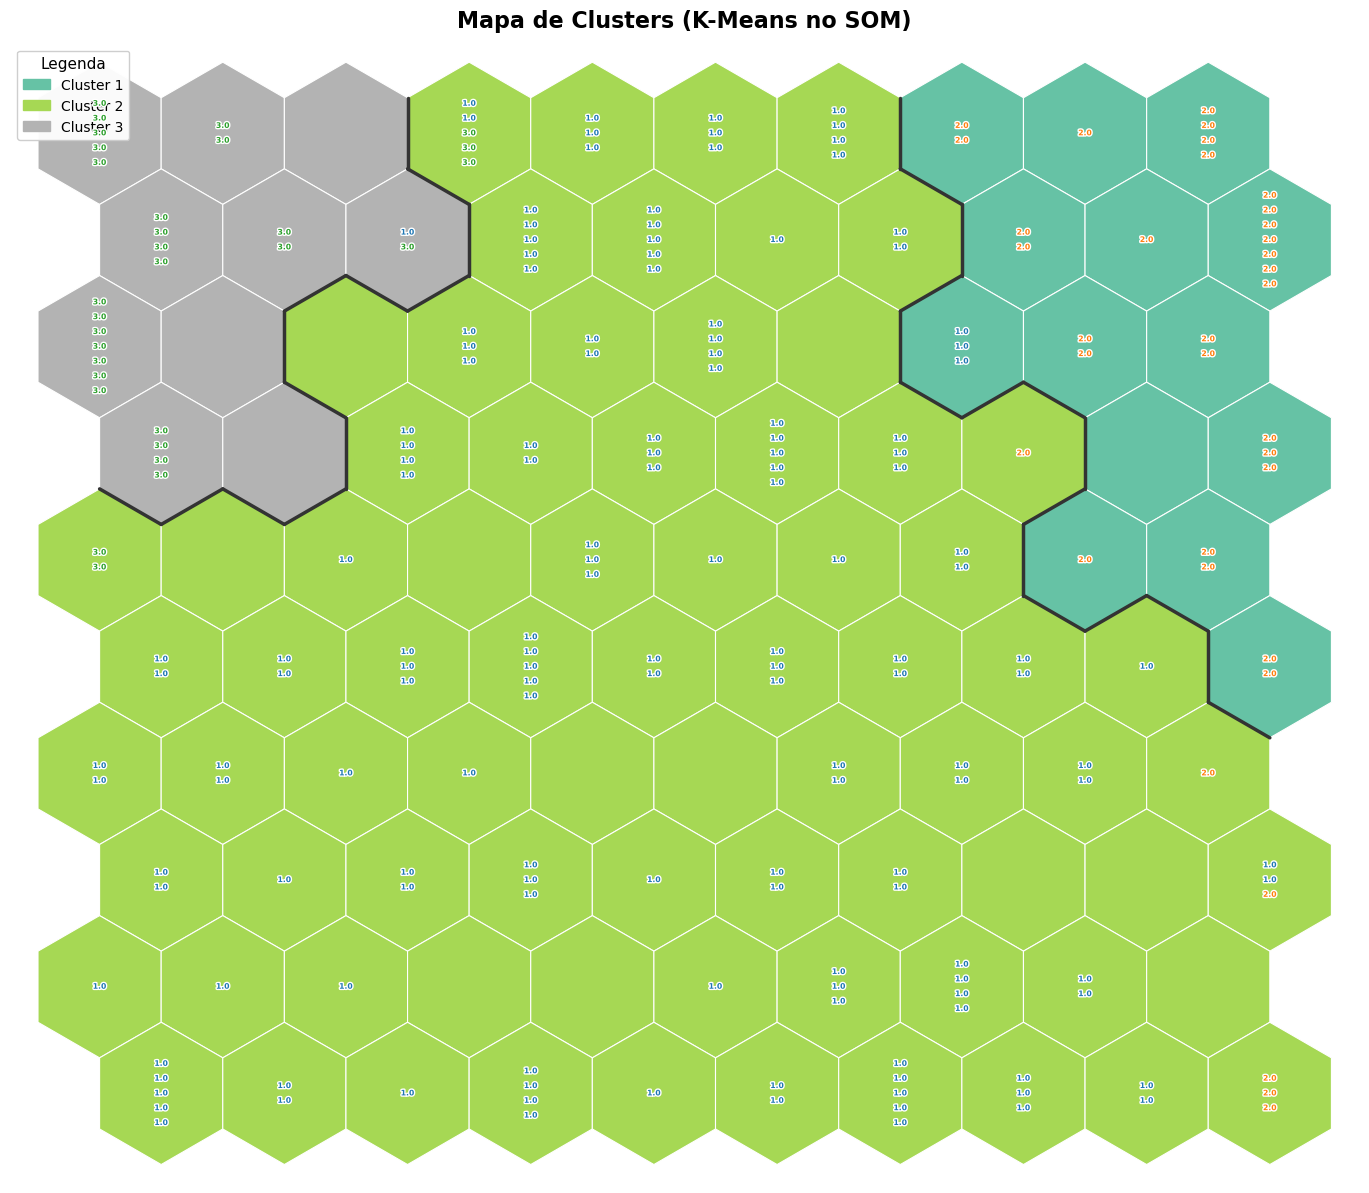

Cluster SOM,Cluster 1,Cluster 2,Cluster 3
Classe real,,,
1.0,3,146,1
2.0,29,6,0
3.0,0,5,25


,classe dominante,n_amostras,pureza
Cluster SOM,,,
Cluster 1,2.0,32,0.9062
Cluster 2,1.0,157,0.9299
Cluster 3,3.0,26,0.9615


Pureza global: 0.9302


,ResinaT3,Torixina,Triiodotironina,TSH,Diff_TSH
cluster_som,,,,,
Cluster 1,90.406,17.278,4.316,0.978,0.016
Cluster 2,111.166,9.347,1.766,1.313,2.645
Cluster 3,123.731,3.369,0.977,14.681,18.735


In [48]:
# Agrupamento manual baseado na leitura visual da U-Matrix e dos planos de componentes.
# Os rótulos reais não entram na definição das regiões; são usados somente depois, na avaliação.
#
# A tentativa anterior usando apenas um limiar global da U-Matrix gerou um único grupo,  pois as regiões internas ficaram conectadas após a redistribuição dos neurônios.

# Aqui usamos três regiões manuais:
# - Cluster 1: região superior/direita, associada a maiores valores de Torixina e Triiodotironina;
# - Cluster 2: região central e inferior, que concentra o padrão majoritário/intermediário;
# - Cluster 3: região superior/esquerda, associada a maiores valores de TSH e Diff_TSH.

linhas = np.repeat(np.arange(som_final.m), som_final.n)
colunas = np.tile(np.arange(som_final.n), som_final.m)

# Começamos colocando todos os neurônios no grupo central/majoritário.
cluster_neuronio_manual = np.ones(som_final.n_neurons, dtype=int)

# Região superior/esquerda: área separada pela U-Matrix e marcada por TSH/Diff_TSH mais elevados.
regiao_superior_esquerda = (
    ((linhas <= 3) & (colunas <= 1)) |
    ((linhas <= 1) & (colunas <= 2))
)

# Região superior/direita: área com padrões mais altos de Torixina/Triiodotironina.
regiao_superior_direita = (
    ((linhas <= 4) & (colunas >= 8)) |
    ((linhas <= 2) & (colunas >= 7)) |
    ((linhas == 5) & (colunas == 9))
)

# Numeração dos clusters:
# 0 -> Cluster 1 no relatório
# 1 -> Cluster 2 no relatório
# 2 -> Cluster 3 no relatório
cluster_neuronio_manual[regiao_superior_direita] = 0
cluster_neuronio_manual[regiao_superior_esquerda] = 2

print("Quantidade de grupos manuais:", len(np.unique(cluster_neuronio_manual)))
print("\nQuantidade de neurônios por grupo manual:")
print(pd.Series(cluster_neuronio_manual).value_counts().sort_index())

# Atribui cada paciente ao grupo manual do seu BMU.
cluster_amostra_manual = cluster_neuronio_manual[bmus_final]

print("\nQuantidade de pacientes por grupo manual:")
print(pd.Series(cluster_amostra_manual).value_counts().sort_index())

# Mapa dos grupos manuais.
som_final.plot_cluster_map(
    cluster_neuronio_manual,
    data=X_tensor,
    labels=y_labels,
    colors_dict=cores_classes,
    show_boundaries=True,
)

# Tabela de contingência e pureza dos grupos manuais.
df_comp_manual, tabela_cont_manual, pureza_manual = tabela_contingencia_pureza(
    cluster_amostra_manual,
    y,
)

# Perfil médio das variáveis originais por grupo manual.
perfil_manual = perfil_por_cluster(cluster_amostra_manual)




### Resposta — Exercício 7

> **Observação metodológica:** como a delimitação das regiões foi feita manualmente a partir da U-Matrix e dos planos de componentes, existe um componente de subjetividade nessa etapa. Os rótulos reais foram utilizados somente depois, para avaliar a coerência dos grupos por meio da tabela de contingência e da pureza.


**1) Quantos grupos conseguimos observar?**

A partir da análise visual da U-Matrix, dos planos de componentes e do mapa de clusters, conseguimos observar **claramente três regiões principais** no SOM. No mapa de clusters, essa separação aparece de forma bem visual pelas cores: uma região maior em **verde**, uma região menor em **cinza** e outra região menor em **azul-esverdeado**. Essa divisão faz sentido com a própria estrutura do problema, já que a base possui três diagnósticos possíveis para a tireoide.

No agrupamento manual, foram encontrados **3 grupos**, com a seguinte distribuição de pacientes:

- Grupo manual 0: **32 pacientes**;
- Grupo manual 1: **157 pacientes**;
- Grupo manual 2: **26 pacientes**.

Essa distribuição mostra que existe um grupo dominante, ocupando a maior parte do mapa, e dois grupos menores localizados em regiões mais específicas. Isso fica bem claro no mapa colorido: o grupo em **verde** ocupa praticamente toda a região central e inferior da malha, enquanto o grupo em **cinza** aparece mais concentrado na parte superior/esquerda e o grupo em **azul-esverdeado** aparece mais na parte superior/direita.

O ponto mais importante é que essa separação manual não foi feita diretamente pelos rótulos reais, mas sim pela leitura da estrutura do mapa. A U-Matrix mostra onde os neurônios vizinhos estão mais distantes entre si, funcionando como possíveis fronteiras. Já os planos de componentes ajudam a entender o que cada região significa em termos das variáveis hormonais. No mapa de clusters, as linhas de fronteira também deixam bem visível a separação entre essas três áreas.

O resultado também ficou forte numericamente. As purezas dos três grupos foram aproximadamente **0,9063**, **0,9299** e **0,9615**, respectivamente, e a pureza global foi **0,9302**. Isso indica que, mesmo fazendo a divisão pela leitura do mapa, os grupos ficaram bastante coerentes com as classes reais.

---

**2) Quais são as características de cada grupo?**

**Cluster 1 — perfil associado ao hipertireoidismo**

O Cluster 1 ficou associado principalmente à classe real `2.0`. Pela tabela de contingência, esse cluster concentrou **29 pacientes da classe 2.0** e apenas **3 pacientes da classe 1.0**, sem pacientes da classe `3.0`. Isso mostra que ele ficou bem definido.

No mapa de clusters, esse grupo aparece na região **azul-esverdeada**, localizada principalmente na parte superior/direita da malha. Essa localização conversa bem com os planos de componentes, porque nessa região observamos valores mais elevados de `Torixina` e `Triiodotironina`.

Olhando para o perfil médio das variáveis, esse grupo apresenta `Torixina` média aproximadamente igual a **17,278** e `Triiodotironina` média aproximadamente igual a **4,316**. Ao mesmo tempo, o `TSH` médio ficou baixo, aproximadamente **0,978**, e o `Diff_TSH` ficou próximo de zero.

Esse padrão é compatível com um perfil de hipertireoidismo, pois o grupo se diferencia pelo aumento dos hormônios tireoidianos. Então, visualmente e numericamente, esse cluster ficou bem coerente: aparece em uma região específica do mapa e possui características hormonais bem diferentes do grupo normal e do grupo associado ao hipotireoidismo.

---

**Cluster 2 — perfil normal ou intermediário**

O Cluster 2 é o maior grupo do mapa, com **157 pacientes**. Ele concentrou principalmente a classe real `1.0`, com **146 pacientes**, mas também recebeu **6 pacientes da classe 2.0** e **5 pacientes da classe 3.0**.

No mapa de clusters, esse grupo aparece em **verde** e ocupa a maior parte da malha, principalmente a região central e inferior. Isso faz sentido, porque a classe normal é a mais numerosa da base. Como esses pacientes possuem valores hormonais menos extremos, eles acabam formando uma região maior e mais contínua no SOM.

Pelas médias, esse grupo apresenta `Torixina` em torno de **9,347**, `Triiodotironina` em torno de **1,766**, `TSH` em torno de **1,313** e `Diff_TSH` em torno de **2,645**. Ou seja, ele não apresenta valores tão altos de `Torixina` e `Triiodotironina` como o Cluster 1, nem valores tão altos de `TSH` e `Diff_TSH` como o Cluster 3.

Por isso, interpretamos esse grupo como o perfil normal ou intermediário. Ele funciona como a região central da base. Os poucos pacientes das classes `2.0` e `3.0` que caíram nesse cluster provavelmente são casos menos extremos, mais próximos do padrão normal.

---

**Cluster 3 — perfil associado ao hipotireoidismo**

O Cluster 3 ficou associado principalmente à classe real `3.0`. Pela tabela de contingência, ele concentrou **25 pacientes da classe 3.0**, apenas **1 paciente da classe 1.0** e nenhum paciente da classe `2.0`. Isso mostra que esse grupo também ficou muito bem separado.

No mapa de clusters, esse grupo aparece em **cinza**, localizado principalmente na região superior/esquerda da malha. Essa região bate com os planos de componentes de `TSH` e `Diff_TSH`, que aparecem com cores mais fortes nessa parte do mapa, indicando valores elevados dessas variáveis.

O perfil médio desse cluster é bem marcado: `TSH` médio aproximadamente igual a **14,681** e `Diff_TSH` médio aproximadamente igual a **18,735**, valores muito superiores aos dos outros grupos. Ao mesmo tempo, `Torixina` e `Triiodotironina` ficam mais baixas, com médias aproximadas de **3,369** e **0,977**.

Esse comportamento é compatível com um perfil de hipotireoidismo. Ou seja, esse cluster se diferencia principalmente pelo aumento de `TSH` e `Diff_TSH`, acompanhado de valores menores dos hormônios tireoidianos.

---

**Comentário pelas cores dos gráficos**

A leitura pelas cores ajuda bastante na interpretação. No mapa de clusters, conseguimos ver três regiões bem definidas: o **verde** como grupo majoritário, o **cinza** como uma região mais específica na parte superior/esquerda e o **azul-esverdeado** como outra região específica na parte superior/direita. Essa separação visual combina com a tabela de contingência e com os perfis médios dos clusters.

Nos planos de componentes, as cores mais quentes indicam valores maiores das variáveis. Assim, vemos que a região associada ao Cluster 3 tem valores mais altos em `TSH` e `Diff_TSH`, enquanto a região associada ao Cluster 1 tem valores mais altos em `Torixina` e `Triiodotironina`. Já a região verde, mais central e dominante, apresenta valores mais intermediários, o que reforça sua interpretação como grupo normal.

Dessa forma, as cores não estão apenas separando visualmente o mapa. Elas ajudam a mostrar que cada região tem um significado clínico diferente. O grupo azul-esverdeado está mais ligado ao aumento dos hormônios tireoidianos, o grupo cinza está mais ligado ao aumento de `TSH` e `Diff_TSH`, e o grupo verde representa o perfil mais comum e intermediário da base.

---

**Conclusão do exercício**

A análise manual mostrou que o SOM organizou os pacientes de forma bem interpretável. Conseguimos observar três regiões principais: uma associada ao hipertireoidismo, outra associada ao padrão normal/intermediário e outra associada ao hipotireoidismo.

A separação mais clara ocorreu nos grupos extremos. O Cluster 1 ficou bem associado à classe `2.0`, com valores altos de `Torixina` e `Triiodotironina`. Já o Cluster 3 ficou bem associado à classe `3.0`, com valores altos de `TSH` e `Diff_TSH`. O Cluster 2 concentrou a classe `1.0` e funcionou como a região central do mapa, recebendo também alguns pacientes das outras classes que estavam mais próximos do padrão normal.

Portanto, o agrupamento manual ficou coerente com a análise visual da U-Matrix, dos planos de componentes e do mapa de clusters. A pureza global de aproximadamente **0,9302** reforça que a separação foi boa, mesmo sem usar os rótulos reais durante o treinamento do SOM. Assim, o mapa não apenas reduziu a dimensionalidade dos dados, mas também revelou uma estrutura clínica bem clara entre os perfis de tireoide.



## Conclusão geral

Nesta lista, utilizamos o SOM como uma ferramenta de exploração **não supervisionada** para analisar uma base de diagnóstico de doenças da tireoide. A ideia principal foi verificar se, mesmo sem usar os rótulos reais durante o treinamento, o mapa seria capaz de organizar os pacientes em regiões coerentes com os diferentes perfis clínicos. O treinamento seguiu o padrão visto em aula, com uma primeira fase de organização global do mapa e uma segunda fase de ajuste mais fino dos neurônios.

Ao longo dos experimentos, ficou claro que os hiperparâmetros influenciam bastante a qualidade final do mapa. No teste do tamanho da grade, o aumento do número de neurônios reduziu o Erro de Quantização: a grade $5 \times 5$ terminou com QE aproximadamente igual a **0,1018**, a grade $10 \times 10$ com QE aproximadamente igual a **0,0765** e a grade $20 \times 20$ com QE aproximadamente igual a **0,0648**. Porém, apesar da grade $20 \times 20$ apresentar o menor erro, ela possui 400 neurônios para apenas 215 pacientes, o que pode deixar o mapa muito esparso e menos interpretável. Por isso, a grade $10 \times 10$ acabou sendo uma escolha mais equilibrada, pois reduziu bem o erro em relação à grade menor, mas ainda manteve uma estrutura visual mais simples de analisar.

A taxa de aprendizado também teve um papel importante. Uma taxa mais alta, como `eta_start = 0.90`, gerou o menor QE final, aproximadamente **0,0742**, mostrando que os neurônios se aproximaram bem dos dados. Porém, essa configuração apresentou TE final maior, aproximadamente **0,0791**, indicando pior preservação topológica. Já a taxa intermediária, `eta_start = 0.50`, apresentou QE muito próximo, aproximadamente **0,0765**, mas com TE final bem menor, aproximadamente **0,0465**. Assim, a taxa intermediária foi mais adequada, pois equilibrava melhor aproximação dos dados e organização do mapa.

O raio de vizinhança inicial também mostrou esse mesmo tipo de compromisso. Com `sigma_start = 1.0`, o SOM teve o menor QE final, aproximadamente **0,0695**, mas apresentou o pior TE final, aproximadamente **0,0977**. Isso indica que o mapa ficou muito local desde o início, conseguindo ajustar bem os pontos individualmente, mas perdendo qualidade na organização global. Já `sigma_start = 5.0` apresentou o melhor TE, aproximadamente **0,0465**, mostrando que uma vizinhança intermediária ajudou os neurônios a se organizarem melhor como conjunto. O valor maior, `sigma_start = 8.0`, também ajudou na organização global, mas não superou o desempenho do sigma intermediário.

Nos testes de topologia e função de vizinhança, a combinação `hexagonal + gaussian` foi a mais adequada do ponto de vista da preservação topológica e da leitura visual da U-Matrix. Embora algumas combinações com `bubble` tenham apresentado menor QE, seus valores de TE foram bem maiores. Isso mostra que, no SOM, não basta apenas aproximar os dados dos neurônios vencedores; também é importante preservar a relação de vizinhança entre as observações. Nesse sentido, a topologia hexagonal com vizinhança gaussiana gerou uma organização mais suave e interpretável.

Com base nesses resultados, escolhemos como configuração final uma grade $10 \times 10$, com topologia `hexagonal`, vizinhança `gaussian`, inicialização por `PCA`, `eta_start = 0.5` e `sigma_start = 5`. No treinamento final, o SOM apresentou QE final aproximadamente igual a **0,0765** e TE final aproximadamente igual a **0,0465**, valores coerentes com uma configuração intermediária, estável e fácil de interpretar.

Depois do treinamento, aplicamos o K-Means sobre os pesos dos neurônios do SOM, usando $K = 3$, pois a base possui três diagnósticos possíveis. Essa etapa permitiu dividir a malha em três regiões principais. A tabela de contingência mostrou que a classe real `1.0` ficou concentrada principalmente no Cluster 2, com **150 pacientes**. A classe `2.0` ficou principalmente no Cluster 1, com **24 pacientes**, embora alguns casos tenham sido associados ao Cluster 2. Já a classe `3.0` ficou principalmente no Cluster 3, com **24 pacientes**, com poucos casos no Cluster 2. A pureza global do agrupamento com K-Means foi aproximadamente **0,9209**, um valor alto para um método não supervisionado.

Na análise manual da U-Matrix e do mapa de clusters, também conseguimos observar três regiões principais de forma bem clara: uma região maior em verde, associada ao grupo normal/intermediário, uma região em azul-esverdeado, associada ao perfil de hipertireoidismo, e uma região em cinza, associada ao perfil de hipotireoidismo. Essa leitura ficou consistente com os planos de componentes. O grupo associado ao hipertireoidismo apresentou valores mais altos de `Torixina` e `Triiodotironina`, enquanto o grupo associado ao hipotireoidismo apresentou valores mais altos de `TSH` e `Diff_TSH`. Já o grupo central apresentou valores mais intermediários, funcionando como o padrão normal da base. A pureza global do agrupamento manual foi aproximadamente **0,9302**, reforçando que a separação visual também foi coerente com as classes reais.

Portanto, os resultados indicam que o SOM conseguiu capturar uma estrutura clínica relevante nos dados. Mesmo sem utilizar os diagnósticos durante o treinamento, o mapa organizou os pacientes em regiões bastante próximas das classes reais. Além disso, a U-Matrix, os planos de componentes, o mapa de ativação e o mapa de clusters ajudaram a interpretar não apenas a separação dos grupos, mas também quais variáveis hormonais estavam por trás dessa separação. Assim, a combinação entre SOM, análise visual e K-Means se mostrou útil tanto para reduzir a dimensionalidade dos dados quanto para entender qualitativamente os perfis clínicos presentes na base.
